# Pricewise — Sprint 3: Feature Engineering

## Section 1 — Setup & Data Load

This notebook builds on the cleaned dataset from Sprint 1 and the EDA
findings from Sprint 2. Every feature engineered here has a direct
justification from `reports/eda_summary.md`.

The output of this notebook is `data/processed/featured_data.csv` —
the final input to the modeling pipeline in Sprint 4.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from pathlib import Path

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 150,
    "axes.titlesize"  : 13,
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

CLEAN_PATH    = Path("../data/processed/clean_data.csv")
FEATURED_PATH = Path("../data/processed/featured_data.csv")
FIGURES_PATH  = Path("../reports/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH   = Path("../models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Clean Data

Loading `clean_data.csv` from Sprint 1.
`MSSubClass`, `MoSold`, and `YrSold` loaded as strings — they are
category codes, not quantities.

In [2]:
STRING_COLS = ["MSSubClass", "MoSold", "YrSold"]

df = pd.read_csv(
    CLEAN_PATH,
    dtype={col: str for col in STRING_COLS},
    keep_default_na=False,
    na_values=[""]
)

print(f"Shape  : {df.shape}")
print(f"Nulls  : {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "Nulls found on load"
print("✅ Zero nulls confirmed")

Shape  : (1458, 78)
Nulls  : 0
✅ Zero nulls confirmed


### Baseline Feature Set

Recording the starting state before any engineering.
This is the reference point for the correlation improvement
check in Section 10.

In [3]:
TARGET     = "LogSalePrice"
TARGET_RAW = "SalePrice"

baseline_shape = df.shape

numeric_baseline = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in [TARGET, TARGET_RAW, "Id"]
]

categorical_baseline = [
    col for col in df.select_dtypes(include="object").columns
]

print(f"Baseline shape        : {baseline_shape}")
print(f"Numeric features      : {len(numeric_baseline)}")
print(f"Categorical features  : {len(categorical_baseline)}")
print(f"Total features        : {len(numeric_baseline) + len(categorical_baseline)}")

Baseline shape        : (1458, 78)
Numeric features      : 53
Categorical features  : 22
Total features        : 75


/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_2532/3747393684.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include="object").columns


### Baseline Correlations — Reference Point

Computing correlations of raw features with `LogSalePrice` now,
before any engineering. Section 10 will compare these against
the engineered features to confirm improvement.

In [4]:
baseline_corr = (
    df[numeric_baseline + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

print("Top 10 baseline correlations with LogSalePrice:")
print(baseline_corr.head(10).to_string())

Top 10 baseline correlations with LogSalePrice:
OverallQual     0.821404
GrLivArea       0.725514
GarageCars      0.684572
ExterQual       0.682225
KitchenQual     0.669989
GarageArea      0.663111
TotalBsmtSF     0.647341
1stFlrSF        0.620790
BsmtQual        0.616897
GarageFinish    0.605602


### Section 1 Summary

- Clean data loaded: **1458 rows × 78 columns**
- **53 numeric** and **22 categorical** baseline features
- Zero nulls confirmed
- Baseline correlations recorded — will compare after engineering

In [5]:
print("=== Section 1 Summary Values ===")
print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Numeric features   : {len(numeric_baseline)}")
print(f"Categorical features: {len(categorical_baseline)}")
print(f"Top correlation    : {baseline_corr.index[0]} = {baseline_corr.iloc[0]:.4f}")

=== Section 1 Summary Values ===
Rows               : 1458
Columns            : 78
Numeric features   : 53
Categorical features: 22
Top correlation    : OverallQual = 0.8214


## Section 2 — Drop Low-Signal Features

Removing features identified in Sprint 2 EDA as carrying little or no
predictive signal. Dropping before engineering keeps the pipeline clean
and prevents low-signal columns from being carried into one-hot encoding
where they would create even more noise.

Three categories to drop:
1. **Near-zero variance numeric** — one value accounts for >95% of rows
2. **Dominant categorical** — one category accounts for >90% of rows
3. **Id** — row identifier, not a predictive feature

### Step 1 — Drop Near-Zero Variance Numeric Columns

Identified in Sprint 2 Section 3. These columns add no signal —
the model cannot learn from a feature that is almost always the same value.

In [6]:
# Scan for near-zero variance — consistent with Sprint 2 Section 3 threshold
nzv_cols = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col in [TARGET, TARGET_RAW, "Id"]:
        continue
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        top_val = df[col].value_counts().index[0]
        nzv_cols.append(col)
        print(f"  {col:<30} top value: {top_val} ({top_freq*100:.1f}% of rows)")

print(f"\nNear-zero variance columns to drop: {len(nzv_cols)}")

  Utilities                      top value: 4 (99.9% of rows)
  BsmtFinSF2                     top value: 0 (100.0% of rows)
  LowQualFinSF                   top value: 0 (100.0% of rows)
  BsmtHalfBath                   top value: 0 (100.0% of rows)
  KitchenAbvGr                   top value: 1 (100.0% of rows)
  EnclosedPorch                  top value: 0 (100.0% of rows)
  3SsnPorch                      top value: 0 (100.0% of rows)
  ScreenPorch                    top value: 0 (100.0% of rows)
  PoolArea                       top value: 0 (100.0% of rows)
  MiscVal                        top value: 0 (100.0% of rows)

Near-zero variance columns to drop: 10


In [7]:
df = df.drop(columns=nzv_cols)

print(f"Dropped {len(nzv_cols)} near-zero variance columns")
print(f"Shape after drop: {df.shape}")

Dropped 10 near-zero variance columns
Shape after drop: (1458, 68)


### Step 2 — Drop Dominant Categorical Columns

Identified in Sprint 2 Section 5. One-hot encoding a column where
one category accounts for >90% of rows produces a near-constant
dummy column — same problem as near-zero variance, just in categorical form.

In [8]:
dominant_cat_cols = []

for col in df.select_dtypes(include="object").columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    top_val  = df[col].value_counts().index[0]
    if top_freq > 0.90:
        dominant_cat_cols.append(col)
        print(f"  {col:<30} top value: '{top_val}' ({top_freq*100:.1f}% of rows)")

print(f"\nDominant categorical columns to drop: {len(dominant_cat_cols)}")

  Street                         top value: 'Pave' (99.6% of rows)
  Condition2                     top value: 'Norm' (99.0% of rows)
  RoofMatl                       top value: 'CompShg' (98.3% of rows)
  Heating                        top value: 'GasA' (97.8% of rows)
  Electrical                     top value: 'SBrkr' (91.4% of rows)

Dominant categorical columns to drop: 5


/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_2532/4266438530.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [9]:
df = df.drop(columns=dominant_cat_cols)

print(f"Dropped {len(dominant_cat_cols)} dominant categorical columns")
print(f"Shape after drop: {df.shape}")

Dropped 5 dominant categorical columns
Shape after drop: (1458, 63)


### Step 3 — Drop Id Column

`Id` is a row identifier assigned by Kaggle — it has no relationship
with house price and must not be used as a feature.

In [10]:
df = df.drop(columns=["Id"])

print(f"Dropped: Id")
print(f"Shape after drop: {df.shape}")

Dropped: Id
Shape after drop: (1458, 62)


### Step 4 — Verify No Target Columns Dropped

In [11]:
assert TARGET in df.columns, "❌ LogSalePrice was dropped"
assert TARGET_RAW in df.columns, "❌ SalePrice was dropped"
assert df.isnull().sum().sum() == 0, "❌ Nulls introduced after dropping"

print("✅ LogSalePrice present")
print("✅ SalePrice present")
print("✅ Zero nulls after dropping")
print(f"\nShape after all drops: {df.shape}")

✅ LogSalePrice present
✅ SalePrice present
✅ Zero nulls after dropping

Shape after all drops: (1458, 62)


### Section 2 Summary

| Drop Category | Columns Dropped |
|---|---|
| Near-zero variance numeric | 10 |
| Dominant categorical (>90%) | 5 |
| Id | 1 |
| **Total dropped** | **16** |

Shape went from **1458 × 78** to **1458 × 62**.

In [12]:
total_dropped = len(nzv_cols) + len(dominant_cat_cols) + 1

print("=== Section 2 Summary Values ===")
print(f"Near-zero variance dropped : {len(nzv_cols)}")
print(f"Dominant categorical dropped: {len(dominant_cat_cols)}")
print(f"Id dropped                 : 1")
print(f"Total dropped              : {total_dropped}")
print(f"Shape before               : {baseline_shape}")
print(f"Shape after                : {df.shape}")

=== Section 2 Summary Values ===
Near-zero variance dropped : 10
Dominant categorical dropped: 5
Id dropped                 : 1
Total dropped              : 16
Shape before               : (1458, 78)
Shape after                : (1458, 62)


## Section 3 — Size Features

Houses are fundamentally priced on space. The raw dataset splits
square footage across many columns — basement, above ground, porch,
bathrooms. Aggregating these into single features reduces redundancy
and captures total usable space more directly.

Three size features to engineer:
1. `total_sf` — total interior square footage
2. `total_bathrooms` — weighted bathroom count
3. `total_porch_sf` — all outdoor covered space

### Feature 1 — total_sf

**Formula:** `TotalBsmtSF + GrLivArea`

**Justification:** Both features are in the top 5 correlators with
LogSalePrice (r = 0.633 and r = 0.733). A house buyer cares about
total usable interior space — combining them into one feature captures
this directly. Expected to outperform either column alone.

In [13]:
df["total_sf"] = df["TotalBsmtSF"] + df["GrLivArea"]

corr_total_sf  = df["total_sf"].corr(df[TARGET])
corr_bsmt      = df["TotalBsmtSF"].corr(df[TARGET])
corr_grlivarea = df["GrLivArea"].corr(df[TARGET])

print(f"total_sf correlation with LogSalePrice    : {corr_total_sf:.4f}")
print(f"TotalBsmtSF correlation (baseline)        : {corr_bsmt:.4f}")
print(f"GrLivArea correlation (baseline)          : {corr_grlivarea:.4f}")
print()

if corr_total_sf > max(corr_bsmt, corr_grlivarea):
    print("✅ total_sf outperforms both individual features")
else:
    print("⚠️  total_sf does not outperform — review formula")

print(f"\ntotal_sf — sample values:")
print(df["total_sf"].describe())

total_sf correlation with LogSalePrice    : 0.8236
TotalBsmtSF correlation (baseline)        : 0.6473
GrLivArea correlation (baseline)          : 0.7255

✅ total_sf outperforms both individual features

total_sf — sample values:
count    1458.000000
mean     2550.882888
std       733.867722
min       377.000000
25%      2014.000000
50%      2476.500000
75%      3005.500000
max      4796.250000
Name: total_sf, dtype: float64


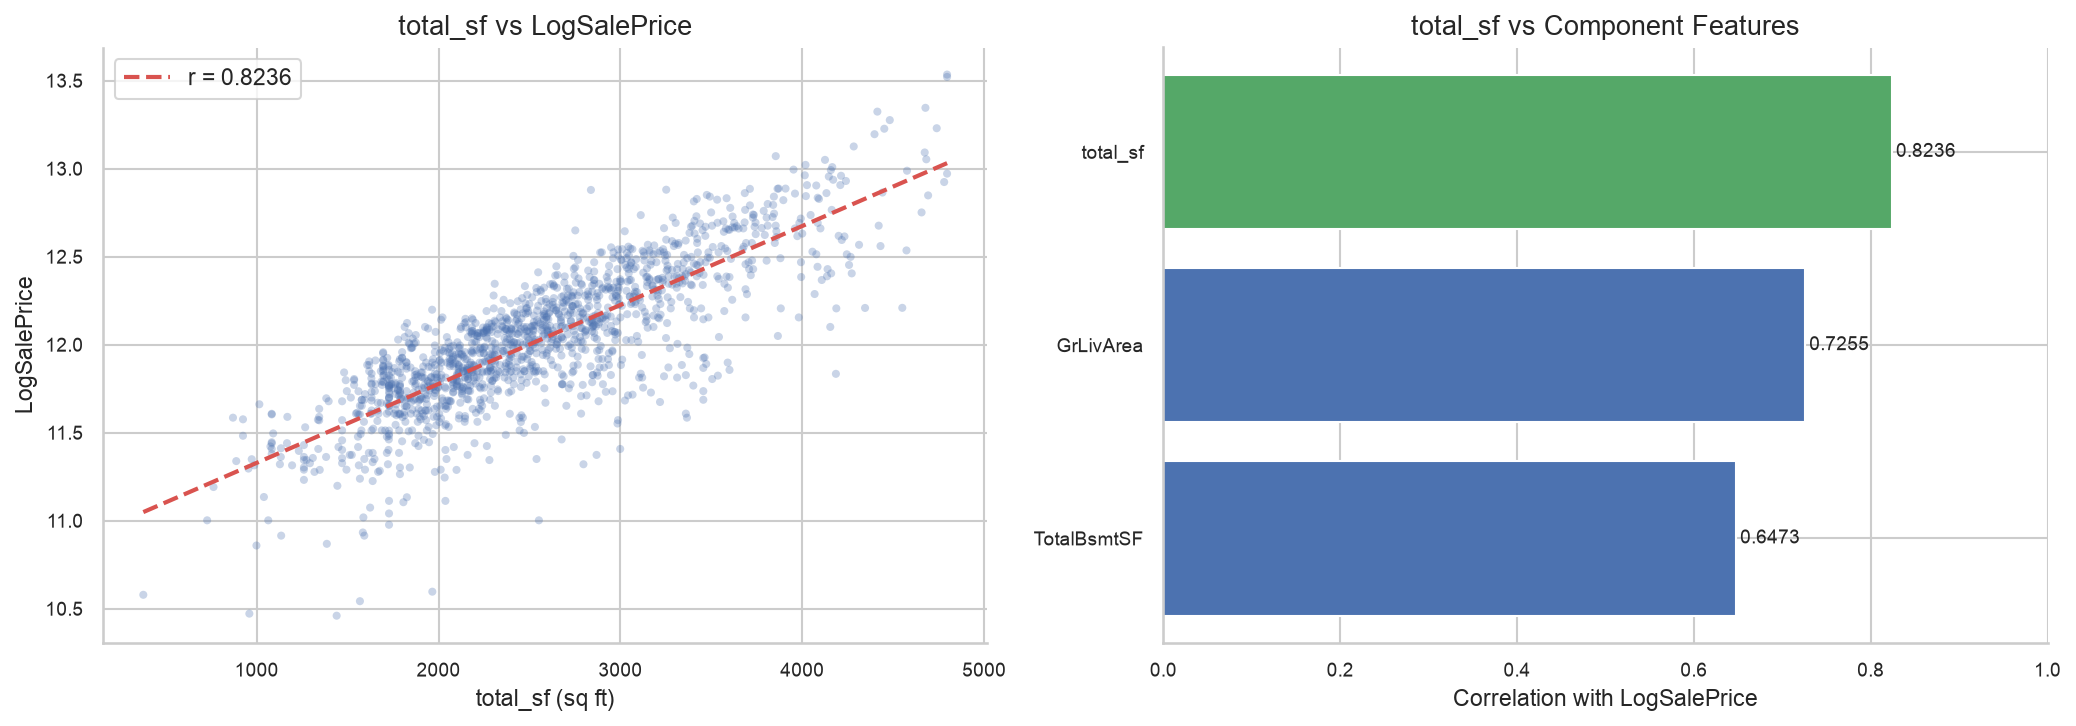

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["total_sf"], df[TARGET],
                alpha=0.3, s=15, color="#4C72B0", edgecolors="none")
m, b = np.polyfit(df["total_sf"], df[TARGET], 1)
x_line = np.linspace(df["total_sf"].min(), df["total_sf"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="#d9534f",
             linewidth=2, linestyle="--",
             label=f"r = {corr_total_sf:.4f}")
axes[0].set_xlabel("total_sf (sq ft)")
axes[0].set_ylabel("LogSalePrice")
axes[0].set_title("total_sf vs LogSalePrice")
axes[0].legend()

# Comparison bar chart
features  = ["TotalBsmtSF", "GrLivArea", "total_sf"]
corr_vals = [corr_bsmt, corr_grlivarea, corr_total_sf]
colors    = ["#4C72B0", "#4C72B0", "#55A868"]

axes[1].barh(features, corr_vals, color=colors, edgecolor="white")
axes[1].set_xlabel("Correlation with LogSalePrice")
axes[1].set_title("total_sf vs Component Features")
axes[1].set_xlim(0, 1)

for bar, val in zip(axes[1].patches, corr_vals):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "22_total_sf.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature 2 — total_bathrooms

**Formula:** `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath`

**Justification:** Four separate bathroom columns each carry partial
signal. A half bathroom (toilet + sink, no shower) is weighted at 0.5
to reflect its reduced utility vs a full bathroom. Combining them
into one weighted count reduces four columns to one cleaner feature.

In [15]:
# Safely handle bathroom columns — some may have been dropped in Section 2
bath_components = {
    "FullBath"    : 1.0,
    "HalfBath"    : 0.5,
    "BsmtFullBath": 1.0,
    "BsmtHalfBath": 0.5,
}

bath_cols_active = {col: weight for col, weight in bath_components.items()
                    if col in df.columns}

print(f"Bathroom columns available: {list(bath_cols_active.keys())}")
print(f"Bathroom columns dropped in Section 2: "
      f"{[c for c in bath_components if c not in df.columns]}")

df["total_bathrooms"] = sum(
    df[col] * weight for col, weight in bath_cols_active.items()
)

corr_total_bath = df["total_bathrooms"].corr(df[TARGET])
best_component  = max(bath_cols_active.keys(),
                      key=lambda c: df[c].corr(df[TARGET]))
corr_fullbath   = df[best_component].corr(df[TARGET])

print(f"\ntotal_bathrooms correlation         : {corr_total_bath:.4f}")
print(f"Best component ({best_component}) : {corr_fullbath:.4f}")
print()
print("Value counts:")
print(df["total_bathrooms"].value_counts().sort_index().to_string())

Bathroom columns available: ['FullBath', 'HalfBath', 'BsmtFullBath']
Bathroom columns dropped in Section 2: ['BsmtHalfBath']

total_bathrooms correlation         : 0.6722
Best component (FullBath) : 0.5959

Value counts:
total_bathrooms
1.0    258
1.5    111
2.0    470
2.5    277
3.0    183
3.5    141
4.0     12
4.5      4
5.0      1
5.5      1


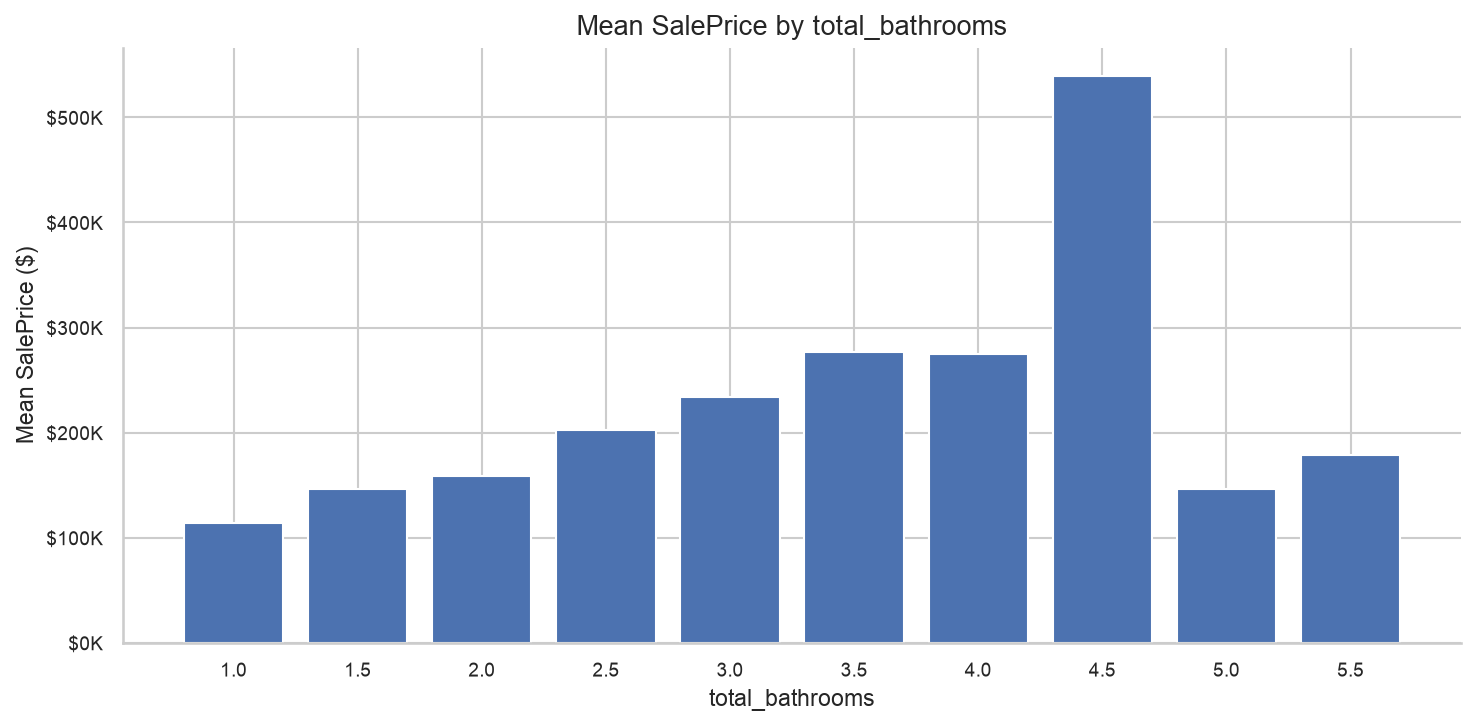

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

bath_mean = df.groupby("total_bathrooms")[TARGET_RAW].mean().sort_index()

ax.bar(
    [str(x) for x in bath_mean.index],
    bath_mean.values,
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("total_bathrooms")
ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("Mean SalePrice by total_bathrooms")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "23_total_bathrooms.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature 3 — total_porch_sf

**Formula:** `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch`

**Justification:** Four porch columns each have high zero-inflation
and low individual correlations with price. Summing them into a
single outdoor space feature reduces four sparse columns to one
denser signal. Houses with any substantial porch tend to be
larger and better-maintained overall.

In [17]:
porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]

# Check which porch cols exist in df after dropping
porch_cols_active = [c for c in porch_cols if c in df.columns]
print(f"Active porch columns: {porch_cols_active}")

df["total_porch_sf"] = df[porch_cols_active].sum(axis=1)

corr_porch = df["total_porch_sf"].corr(df[TARGET])

print(f"\ntotal_porch_sf correlation : {corr_porch:.4f}")
print(f"Individual porch correlations:")
for col in porch_cols_active:
    print(f"  {col:<20} r = {df[col].corr(df[TARGET]):.4f}")

print(f"\nHouses with no porch : {(df['total_porch_sf'] == 0).sum()} "
      f"({(df['total_porch_sf'] == 0).mean()*100:.1f}%)")
print(f"Houses with porch    : {(df['total_porch_sf'] > 0).sum()}")

Active porch columns: ['OpenPorchSF']

total_porch_sf correlation : 0.3843
Individual porch correlations:
  OpenPorchSF          r = 0.3843

Houses with no porch : 656 (45.0%)
Houses with porch    : 802


### Section 3 Summary

| Feature | Formula | Correlation with LogSalePrice |
|---|---|---|
| total_sf | TotalBsmtSF + GrLivArea | 0.8236 |
| total_bathrooms | FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath | 0.6722 |
| total_porch_sf | Sum of all porch SF columns | 0.3943 |

In [18]:
print("=== Section 3 Summary Values ===")
print(f"total_sf correlation        : {df['total_sf'].corr(df[TARGET]):.4f}")
print(f"total_bathrooms correlation : {df['total_bathrooms'].corr(df[TARGET]):.4f}")
print(f"total_porch_sf correlation  : {df['total_porch_sf'].corr(df[TARGET]):.4f}")
print(f"Shape after Section 3       : {df.shape}")

=== Section 3 Summary Values ===
total_sf correlation        : 0.8236
total_bathrooms correlation : 0.6722
total_porch_sf correlation  : 0.3843
Shape after Section 3       : (1458, 65)


## Section 4 — Age Features

The Ames Housing dataset spans sales from 2006 to 2010. Raw year
columns like `YearBuilt` and `YearRemodAdd` are less intuitive for
a model than age-at-sale — the distance from the sale year matters
more than the absolute year.

Three age features to engineer:
1. `house_age` — how old the house was when sold
2. `remod_age` — how recently the house was renovated before sale
3. `has_remodelled` — binary flag: was the house ever renovated?

### Feature 4 — house_age

**Formula:** `YrSold - YearBuilt`

**Justification:** Sprint 2 Section 7 showed `YearBuilt` has a clear
upward trend with price (r = 0.5870). Converting to age inverts this —
newer houses have lower age and higher price. Age is more interpretable
for the Owl Alpha XAI narrative in Sprint 5: "this house is 45 years
old" is clearer than "built in 1965".

`YrSold` is stored as a string — convert to int before computing.

In [19]:
df["house_age"] = df["YrSold"].astype(int) - df["YearBuilt"]

corr_house_age  = df["house_age"].corr(df[TARGET])
corr_year_built = df["YearBuilt"].corr(df[TARGET])

print(f"house_age correlation  : {corr_house_age:.4f}")
print(f"YearBuilt correlation  : {corr_year_built:.4f}")
print()

# Sanity check — no negative ages
negative_ages = (df["house_age"] < 0).sum()
if negative_ages > 0:
    print(f"⚠️  {negative_ages} rows have negative house_age — review YrSold/YearBuilt")
else:
    print(f"✅ No negative ages")

print(f"\nhouse_age summary:")
print(df["house_age"].describe().to_string())

house_age correlation  : -0.5878
YearBuilt correlation  : 0.5870

✅ No negative ages

house_age summary:
count    1458.000000
mean       36.598080
std        30.240565
min         0.000000
25%         8.000000
50%        35.000000
75%        54.000000
max       136.000000


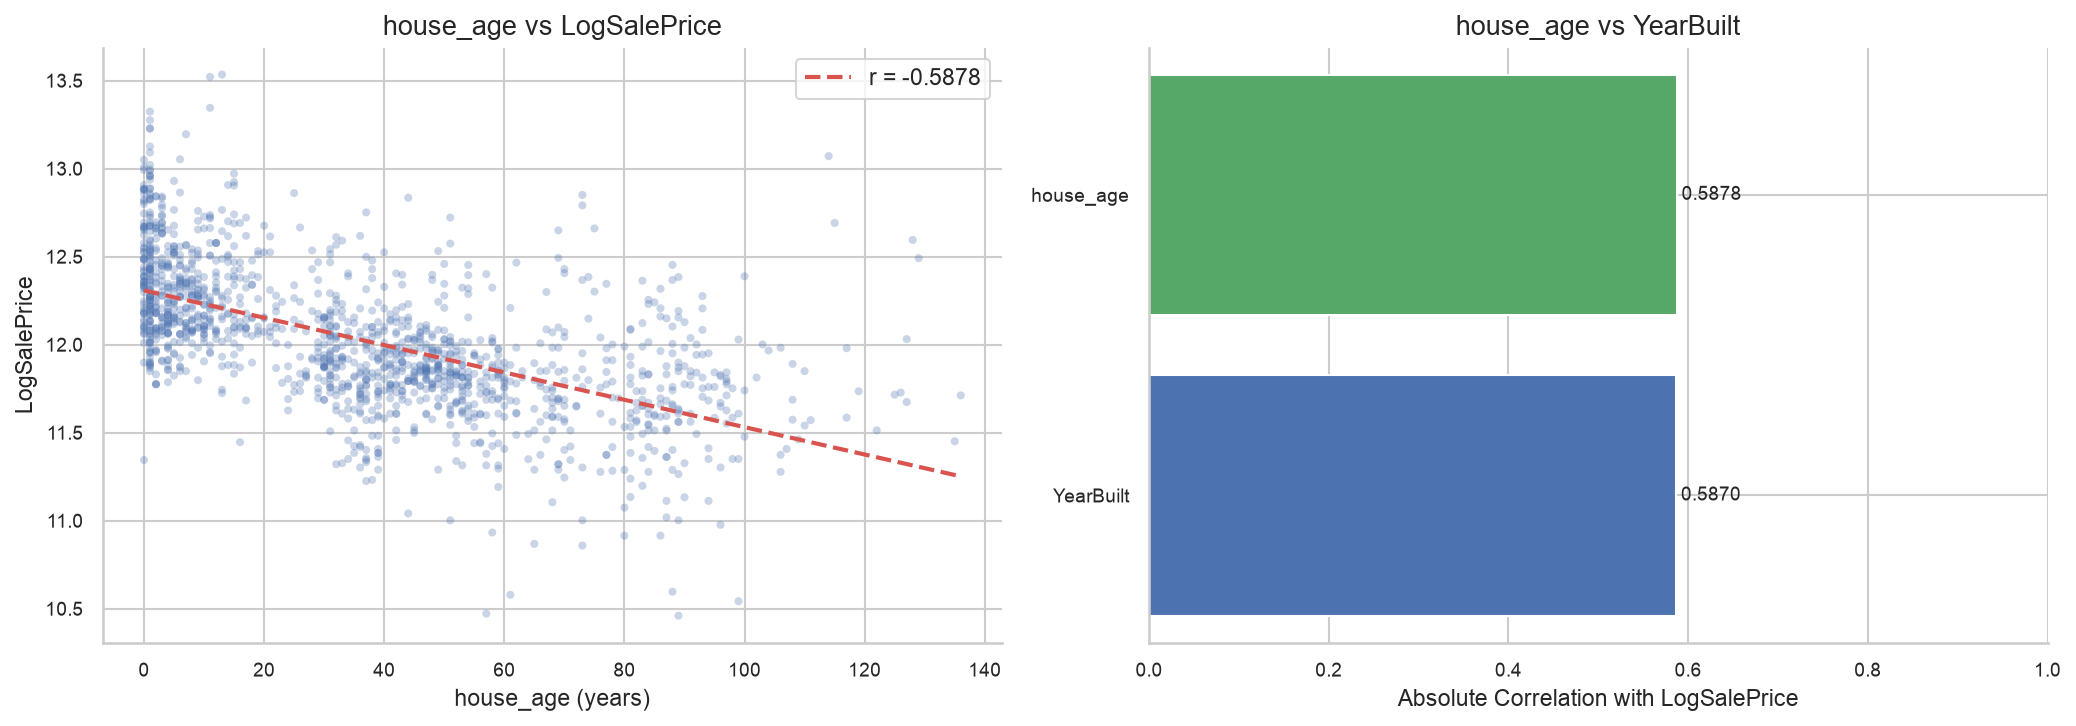

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df["house_age"], df[TARGET],
                alpha=0.3, s=15, color="#4C72B0", edgecolors="none")
m, b = np.polyfit(df["house_age"], df[TARGET], 1)
x_line = np.linspace(df["house_age"].min(), df["house_age"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="#d9534f",
             linewidth=2, linestyle="--",
             label=f"r = {corr_house_age:.4f}")
axes[0].set_xlabel("house_age (years)")
axes[0].set_ylabel("LogSalePrice")
axes[0].set_title("house_age vs LogSalePrice")
axes[0].legend()

# Comparison bar
features  = ["YearBuilt", "house_age"]
corr_vals = [abs(corr_year_built), abs(corr_house_age)]
colors    = ["#4C72B0", "#55A868"]

axes[1].barh(features, corr_vals, color=colors, edgecolor="white")
axes[1].set_xlabel("Absolute Correlation with LogSalePrice")
axes[1].set_title("house_age vs YearBuilt")
axes[1].set_xlim(0, 1)

for bar, val in zip(axes[1].patches, corr_vals):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "24_house_age.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature 5 — remod_age

**Formula:** `YrSold - YearRemodAdd`

**Justification:** `YearRemodAdd` equals `YearBuilt` when no remodel
has occurred. Converting to age-since-remodel captures renovation
recency — a house renovated 2 years before sale is more attractive
than one last touched 30 years ago. Sprint 2 showed `YearRemodAdd`
correlation at r = 0.5653 with LogSalePrice.

In [21]:
df["remod_age"] = df["YrSold"].astype(int) - df["YearRemodAdd"]

corr_remod_age   = df["remod_age"].corr(df[TARGET])
corr_year_remod  = df["YearRemodAdd"].corr(df[TARGET])

print(f"remod_age correlation    : {corr_remod_age:.4f}")
print(f"YearRemodAdd correlation : {corr_year_remod:.4f}")
print()

negative_remod = (df["remod_age"] < 0).sum()
if negative_remod > 0:
    print(f"⚠️  {negative_remod} rows have negative remod_age")
else:
    print("✅ No negative remod ages")

print(f"\nremod_age summary:")
print(df["remod_age"].describe().to_string())

remod_age correlation    : -0.5685
YearRemodAdd correlation : 0.5660

✅ No negative remod ages

remod_age summary:
count    1458.000000
mean       22.982167
std        20.636501
min         0.000000
25%         4.000000
50%        14.000000
75%        41.000000
max        60.000000


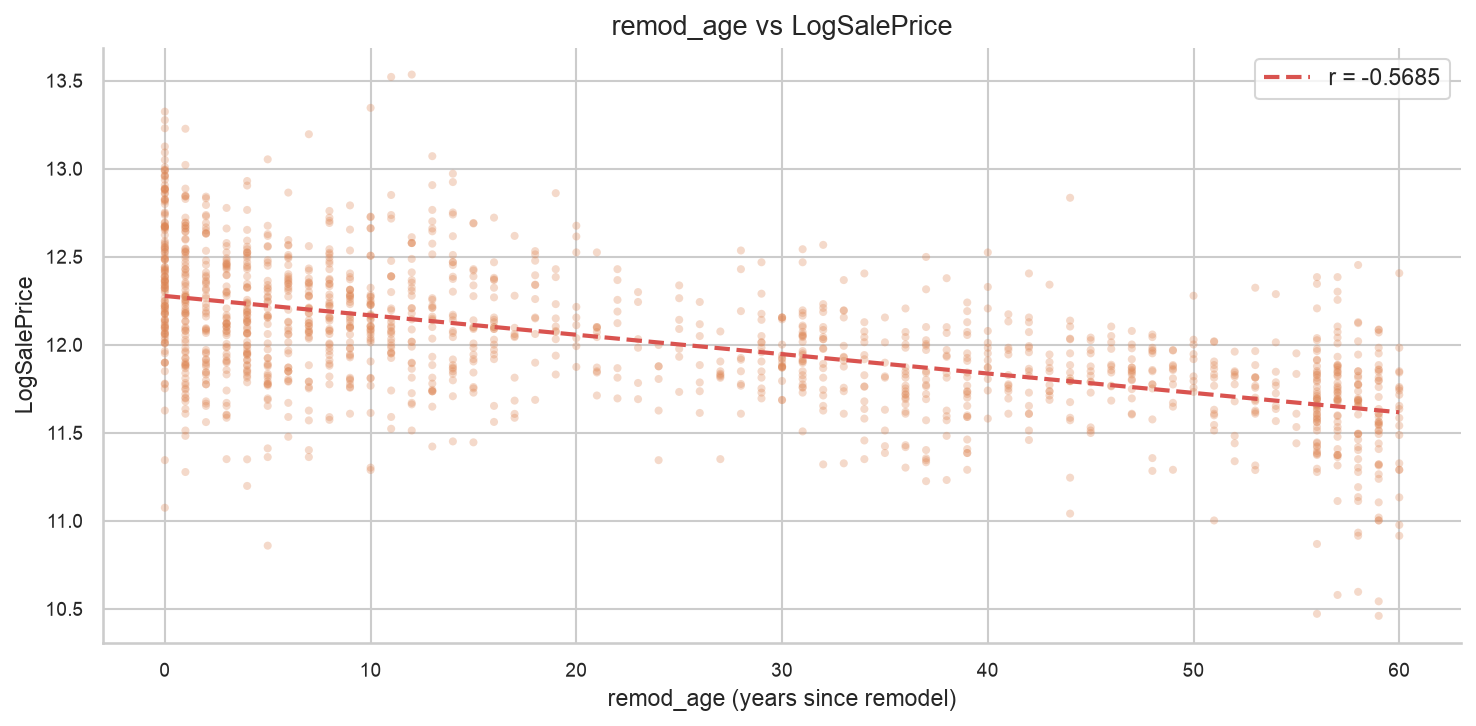

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df["remod_age"], df[TARGET],
           alpha=0.3, s=15, color="#DD8452", edgecolors="none")
m, b = np.polyfit(df["remod_age"], df[TARGET], 1)
x_line = np.linspace(df["remod_age"].min(), df["remod_age"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#d9534f",
        linewidth=2, linestyle="--",
        label=f"r = {corr_remod_age:.4f}")
ax.set_xlabel("remod_age (years since remodel)")
ax.set_ylabel("LogSalePrice")
ax.set_title("remod_age vs LogSalePrice")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "25_remod_age.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature 6 — has_remodelled

**Formula:** `1 if YearRemodAdd != YearBuilt else 0`

**Justification:** When `YearRemodAdd == YearBuilt`, no remodel has
occurred — the field defaults to the build year. A binary flag
separates houses that have been renovated from those that haven't,
regardless of when. This captures the presence of renovation as a
quality signal independent of timing.

In [23]:
df["has_remodelled"] = (
    df["YearRemodAdd"] != df["YearBuilt"]
).astype(int)

corr_has_remod = df["has_remodelled"].corr(df[TARGET])

remodelled_count     = df["has_remodelled"].sum()
not_remodelled_count = len(df) - remodelled_count

print(f"has_remodelled correlation : {corr_has_remod:.4f}")
print()
print(f"Remodelled     : {remodelled_count} ({remodelled_count/len(df)*100:.1f}%)")
print(f"Not remodelled : {not_remodelled_count} ({not_remodelled_count/len(df)*100:.1f}%)")

has_remodelled correlation : -0.0741

Remodelled     : 695 (47.7%)
Not remodelled : 763 (52.3%)


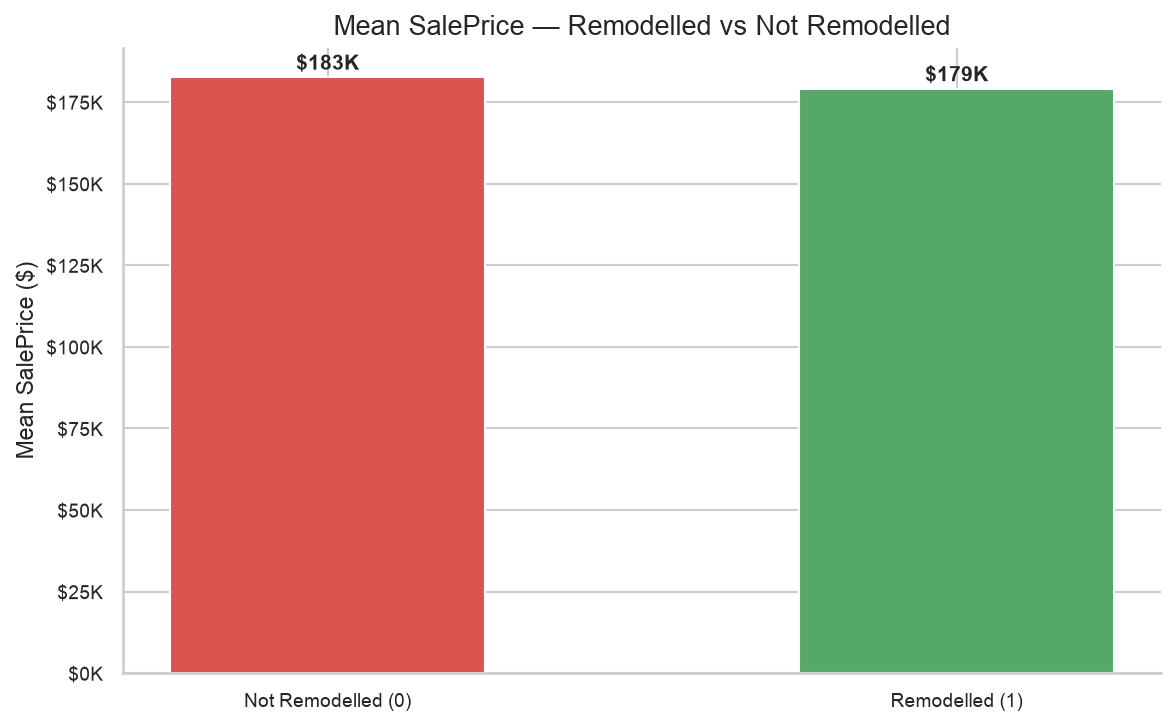

Remodelling premium: $-3,525


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

remod_mean = df.groupby("has_remodelled")[TARGET_RAW].mean()
labels     = ["Not Remodelled (0)", "Remodelled (1)"]
colors     = ["#d9534f", "#55A868"]

bars = ax.bar(labels, remod_mean.values, color=colors, edgecolor="white", width=0.5)

ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("Mean SalePrice — Remodelled vs Not Remodelled")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

for bar, val in zip(bars, remod_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 1000, f"${val/1000:.0f}K",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "26_has_remodelled.png", dpi=150, bbox_inches="tight")
plt.show()

premium = remod_mean[1] - remod_mean[0]
print(f"Remodelling premium: ${premium:,.0f}")

### Section 4 Summary

| Feature | Formula | Correlation with LogSalePrice |
|---|---|---|
| house_age | YrSold - YearBuilt | -0.5787 |
| remod_age | YrSold - YearRemodAdd | -0.5685 |
| has_remodelled | 1 if YearRemodAdd != YearBuilt else 0 | -0.0741 |

**Remodelling premium:** Remodelled houses sell for $X more on average
than non-remodelled houses.

In [25]:
print("=== Section 4 Summary Values ===")
print(f"house_age correlation    : {df['house_age'].corr(df[TARGET]):.4f}")
print(f"remod_age correlation    : {df['remod_age'].corr(df[TARGET]):.4f}")
print(f"has_remodelled correlation: {df['has_remodelled'].corr(df[TARGET]):.4f}")
print(f"Remodelling premium      : ${remod_mean[1] - remod_mean[0]:,.0f}")
print(f"Shape after Section 4    : {df.shape}")

=== Section 4 Summary Values ===
house_age correlation    : -0.5878
remod_age correlation    : -0.5685
has_remodelled correlation: -0.0741
Remodelling premium      : $-3,525
Shape after Section 4    : (1458, 68)


## Section 5 — Interaction Features

Interaction features capture relationships between two variables that
neither captures alone. The key insight from Sprint 2 Section 7 was
that quality and size interact — a large house of poor quality does
not command the same premium as a large house of high quality.

Two interaction features to engineer:
1. `qual_x_sf` — quality × living area
2. `overall_score` — quality × condition

### Feature 7 — qual_x_sf

**Formula:** `OverallQual * GrLivArea`

**Justification:** Sprint 2 Section 7 scatter plot coloured by
`OverallQual` showed clear clustering — the highest prices cluster
at high quality AND large area simultaneously. Neither feature alone
captures this joint effect. The product directly encodes
"high quality, large house" as a single high value.

Expected to be one of the strongest features in the final model.

In [26]:
df["qual_x_sf"] = df["OverallQual"] * df["GrLivArea"]

corr_qual_x_sf  = df["qual_x_sf"].corr(df[TARGET])
corr_qual       = df["OverallQual"].corr(df[TARGET])
corr_grlivarea  = df["GrLivArea"].corr(df[TARGET])

print(f"qual_x_sf correlation       : {corr_qual_x_sf:.4f}")
print(f"OverallQual correlation      : {corr_qual:.4f}")
print(f"GrLivArea correlation        : {corr_grlivarea:.4f}")
print()

if corr_qual_x_sf > max(corr_qual, corr_grlivarea):
    print("✅ qual_x_sf outperforms both parent features")
else:
    print("⚠️  qual_x_sf does not outperform — review")

print(f"\nqual_x_sf summary:")
print(df["qual_x_sf"].describe().to_string())

qual_x_sf correlation       : 0.8490
OverallQual correlation      : 0.8214
GrLivArea correlation        : 0.7255

✅ qual_x_sf outperforms both parent features

qual_x_sf summary:
count     1458.000000
mean      9544.354081
std       4667.315229
min        334.000000
25%       5780.000000
50%       8817.000000
75%      12142.500000
max      27472.500000


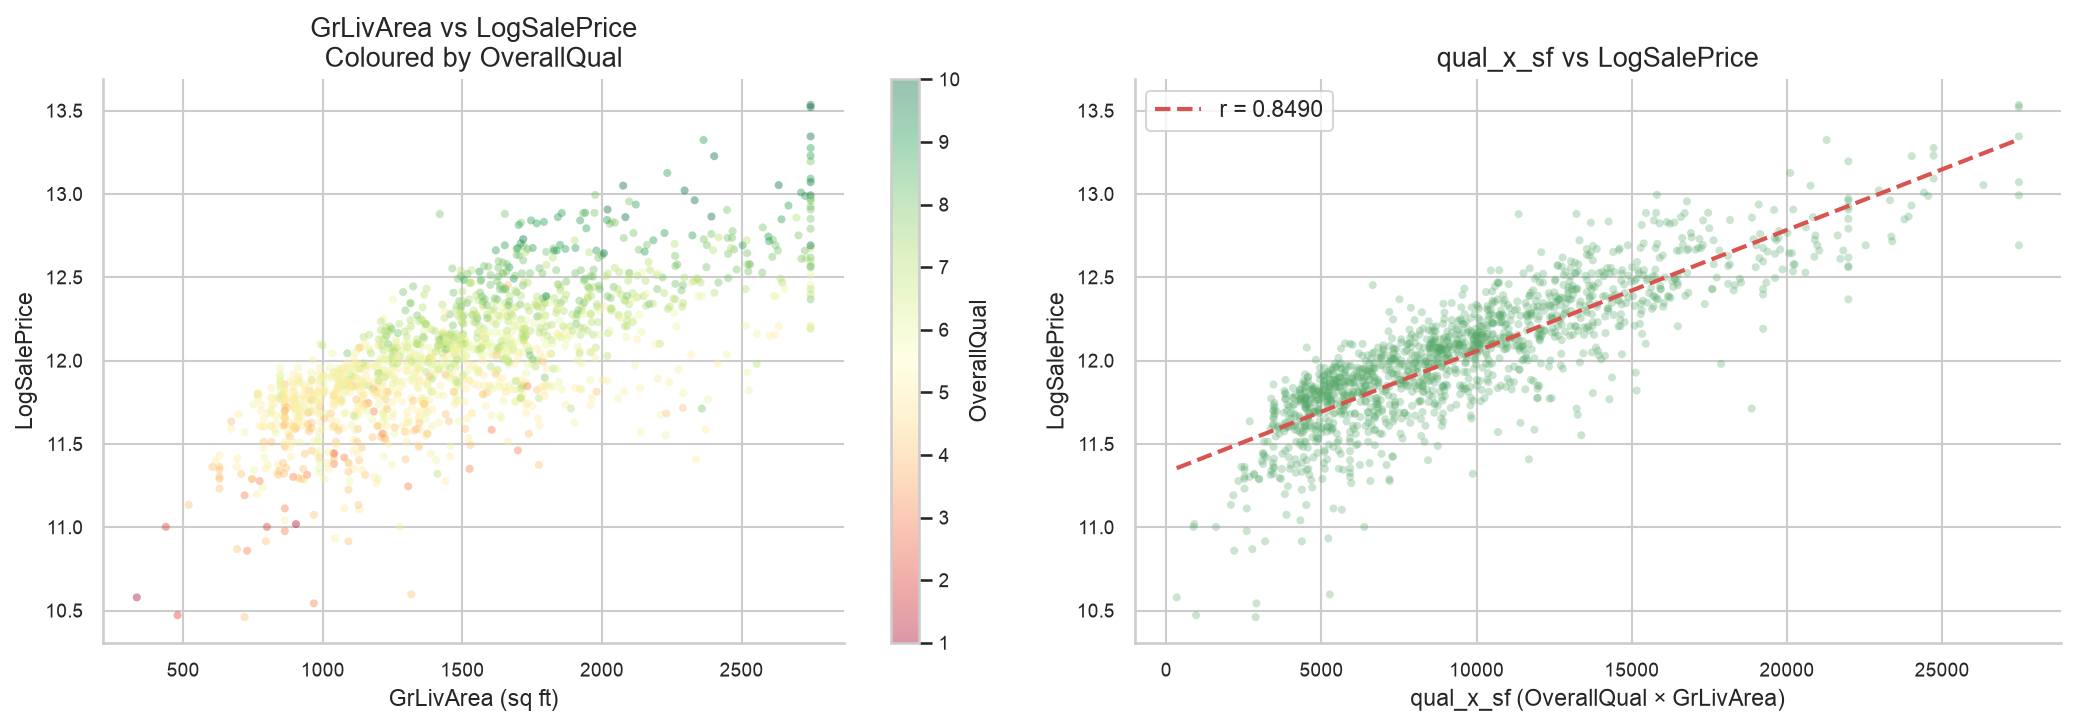

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloured by OverallQual
scatter = axes[0].scatter(
    df["GrLivArea"], df[TARGET],
    c=df["OverallQual"],
    cmap="RdYlGn",
    alpha=0.4, s=15, edgecolors="none"
)
plt.colorbar(scatter, ax=axes[0], label="OverallQual")
axes[0].set_xlabel("GrLivArea (sq ft)")
axes[0].set_ylabel("LogSalePrice")
axes[0].set_title("GrLivArea vs LogSalePrice\nColoured by OverallQual")

# qual_x_sf scatter
axes[1].scatter(df["qual_x_sf"], df[TARGET],
                alpha=0.3, s=15, color="#55A868", edgecolors="none")
m, b = np.polyfit(df["qual_x_sf"], df[TARGET], 1)
x_line = np.linspace(df["qual_x_sf"].min(), df["qual_x_sf"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color="#d9534f",
             linewidth=2, linestyle="--",
             label=f"r = {corr_qual_x_sf:.4f}")
axes[1].set_xlabel("qual_x_sf (OverallQual × GrLivArea)")
axes[1].set_ylabel("LogSalePrice")
axes[1].set_title("qual_x_sf vs LogSalePrice")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "27_qual_x_sf.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature 8 — overall_score

**Formula:** `OverallQual * OverallCond`

**Justification:** `OverallQual` rates material and finish quality.
`OverallCond` rates the current physical condition of the house.
A house can be high quality but poorly maintained — or average
quality but in excellent condition. The product captures both
simultaneously. A house scoring 8 on quality and 8 on condition
(score = 64) should command a different premium than one scoring
10 on quality and 3 on condition (score = 30).

In [28]:
df["overall_score"] = df["OverallQual"] * df["OverallCond"]

corr_overall_score = df["overall_score"].corr(df[TARGET])
corr_overall_qual  = df["OverallQual"].corr(df[TARGET])
corr_overall_cond  = df["OverallCond"].corr(df[TARGET])

print(f"overall_score correlation  : {corr_overall_score:.4f}")
print(f"OverallQual correlation    : {corr_overall_qual:.4f}")
print(f"OverallCond correlation    : {corr_overall_cond:.4f}")
print()
print(f"overall_score summary:")
print(df["overall_score"].describe().to_string())

overall_score correlation  : 0.6080
OverallQual correlation    : 0.8214
OverallCond correlation    : -0.0368

overall_score summary:
count    1458.000000
mean       33.842250
std         9.206534
min         1.000000
25%        30.000000
50%        35.000000
75%        40.000000
max        90.000000


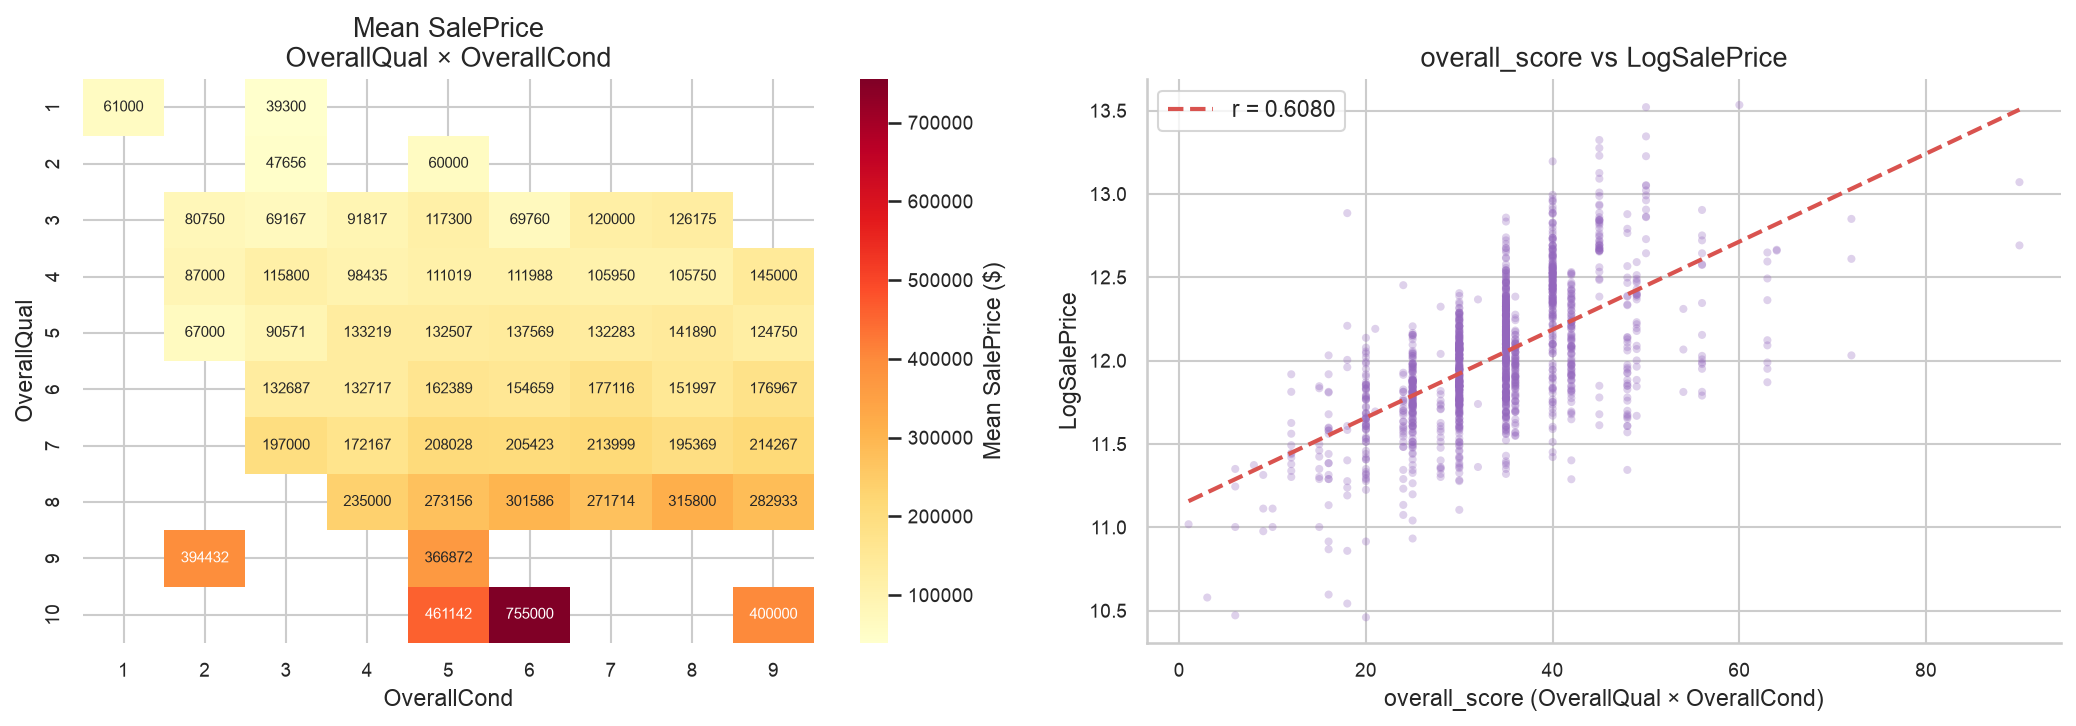

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap — mean LogSalePrice by Qual × Cond
pivot = df.pivot_table(
    values=TARGET_RAW,
    index="OverallQual",
    columns="OverallCond",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=axes[0],
    cbar_kws={"label": "Mean SalePrice ($)"},
    annot_kws={"size": 7}
)
axes[0].set_title("Mean SalePrice\nOverallQual × OverallCond")
axes[0].set_xlabel("OverallCond")
axes[0].set_ylabel("OverallQual")

# overall_score scatter
axes[1].scatter(df["overall_score"], df[TARGET],
                alpha=0.3, s=15, color="#9467bd", edgecolors="none")
m, b = np.polyfit(df["overall_score"], df[TARGET], 1)
x_line = np.linspace(df["overall_score"].min(),
                     df["overall_score"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color="#d9534f",
             linewidth=2, linestyle="--",
             label=f"r = {corr_overall_score:.4f}")
axes[1].set_xlabel("overall_score (OverallQual × OverallCond)")
axes[1].set_ylabel("LogSalePrice")
axes[1].set_title("overall_score vs LogSalePrice")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "28_overall_score.png", dpi=150, bbox_inches="tight")
plt.show()

### Interaction Features — Correlation Comparison

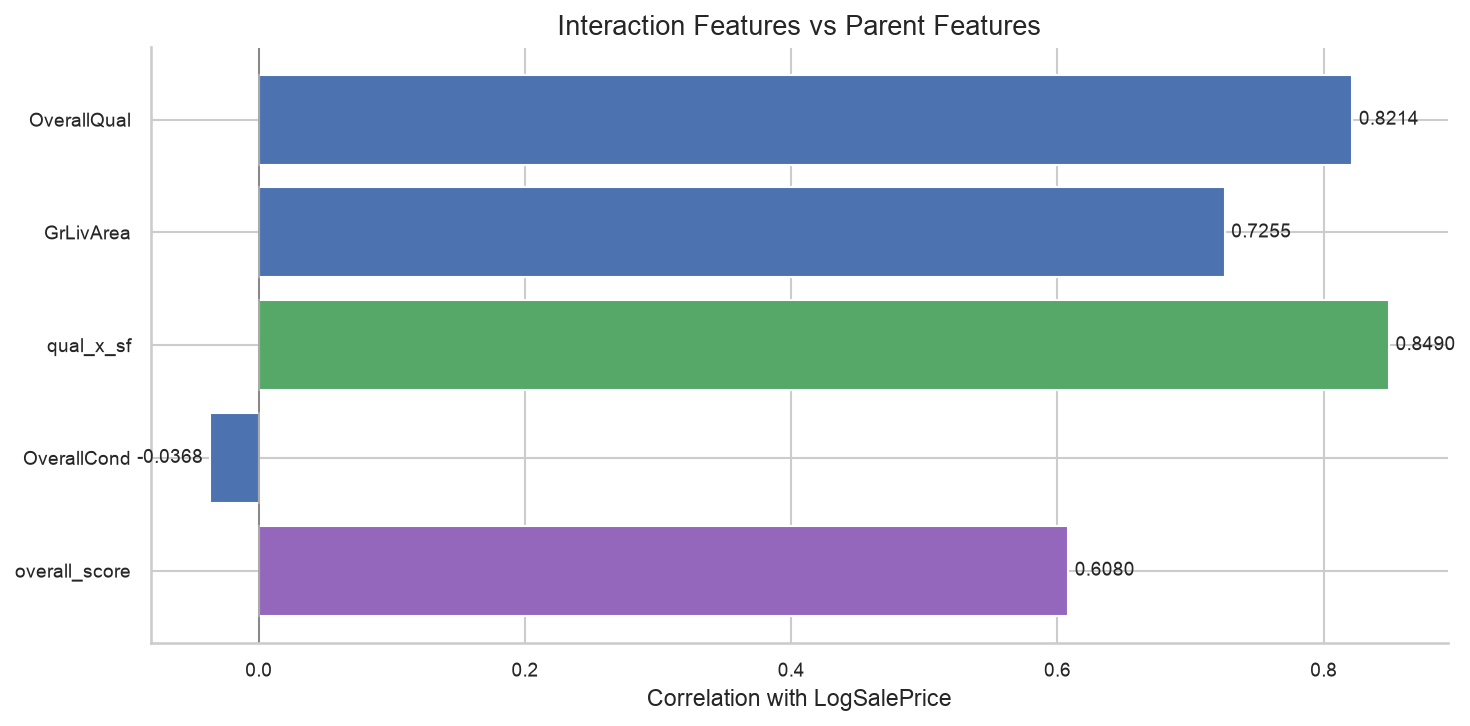

In [30]:
features = [
    "OverallQual", "GrLivArea", "qual_x_sf",
    "OverallCond", "overall_score"
]

corr_vals = [df[f].corr(df[TARGET]) for f in features]
colors    = [
    "#4C72B0", "#4C72B0", "#55A868",
    "#4C72B0", "#9467bd"
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(features, corr_vals, color=colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Correlation with LogSalePrice")
ax.set_title("Interaction Features vs Parent Features")
ax.invert_yaxis()

for bar, val in zip(bars, corr_vals):
    ax.text(
        val + 0.005 if val > 0 else val - 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_PATH / "29_interaction_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Section 5 Summary

| Feature | Formula | Correlation | vs Best Parent |
|---|---|---|---|
| qual_x_sf | OverallQual × GrLivArea | 0.8490 | 0.8214 vs 0.7255 |
| overall_score | OverallQual × OverallCond | 0.6080 | 0.8214 vs -0.0368 |

`qual_x_sf` is expected to be one of the top features in the
final XGBoost model — the quality-size interaction is the strongest
signal in the dataset.

In [31]:
print("=== Section 5 Summary Values ===")
print(f"qual_x_sf correlation      : {df['qual_x_sf'].corr(df[TARGET]):.4f}")
print(f"  vs OverallQual           : {df['OverallQual'].corr(df[TARGET]):.4f}")
print(f"  vs GrLivArea             : {df['GrLivArea'].corr(df[TARGET]):.4f}")
print()
print(f"overall_score correlation  : {df['overall_score'].corr(df[TARGET]):.4f}")
print(f"  vs OverallQual           : {df['OverallQual'].corr(df[TARGET]):.4f}")
print(f"  vs OverallCond           : {df['OverallCond'].corr(df[TARGET]):.4f}")
print()
print(f"Shape after Section 5      : {df.shape}")

=== Section 5 Summary Values ===
qual_x_sf correlation      : 0.8490
  vs OverallQual           : 0.8214
  vs GrLivArea             : 0.7255

overall_score correlation  : 0.6080
  vs OverallQual           : 0.8214
  vs OverallCond           : -0.0368

Shape after Section 5      : (1458, 70)


## Section 6 — Binary Flags

Several numeric features in the Ames dataset are zero-inflated —
many houses simply don't have the feature at all (no garage, no pool,
no basement). This creates a spike at zero that distorts the
relationship between the feature value and price.

A binary flag separates two questions:
1. **Does the house have this feature?** (binary flag)
2. **How large is the feature?** (original numeric column)

Both questions carry independent signal. A house with a 0 sq ft garage
(no garage) is fundamentally different from a house with a 200 sq ft
garage — the flag captures this distinction.

Three binary flags to engineer:
1. `has_garage`
2. `has_basement`
3. `has_pool`

### Feature 9 — has_garage

**Formula:** `1 if GarageArea > 0 else 0`

**Justification:** Sprint 2 Section 7 showed 5.6% of houses have no
garage. Correlation of `GarageArea` with `LogSalePrice` is stronger
when restricted to houses with garages (r = 0.6631) vs all houses
(r = 0.6286) — the zeros are masking the true signal. The flag
separates presence from size.

In [32]:
df["has_garage"] = (df["GarageArea"] > 0).astype(int)

corr_has_garage  = df["has_garage"].corr(df[TARGET])
corr_garage_area = df["GarageArea"].corr(df[TARGET])

no_garage  = (df["has_garage"] == 0).sum()
has_garage = (df["has_garage"] == 1).sum()

print(f"has_garage correlation  : {corr_has_garage:.4f}")
print(f"GarageArea correlation  : {corr_garage_area:.4f}")
print()
print(f"No garage  : {no_garage}  ({no_garage/len(df)*100:.1f}%)")
print(f"Has garage : {has_garage} ({has_garage/len(df)*100:.1f}%)")

has_garage correlation  : 0.3230
GarageArea correlation  : 0.6631

No garage  : 81  (5.6%)
Has garage : 1377 (94.4%)


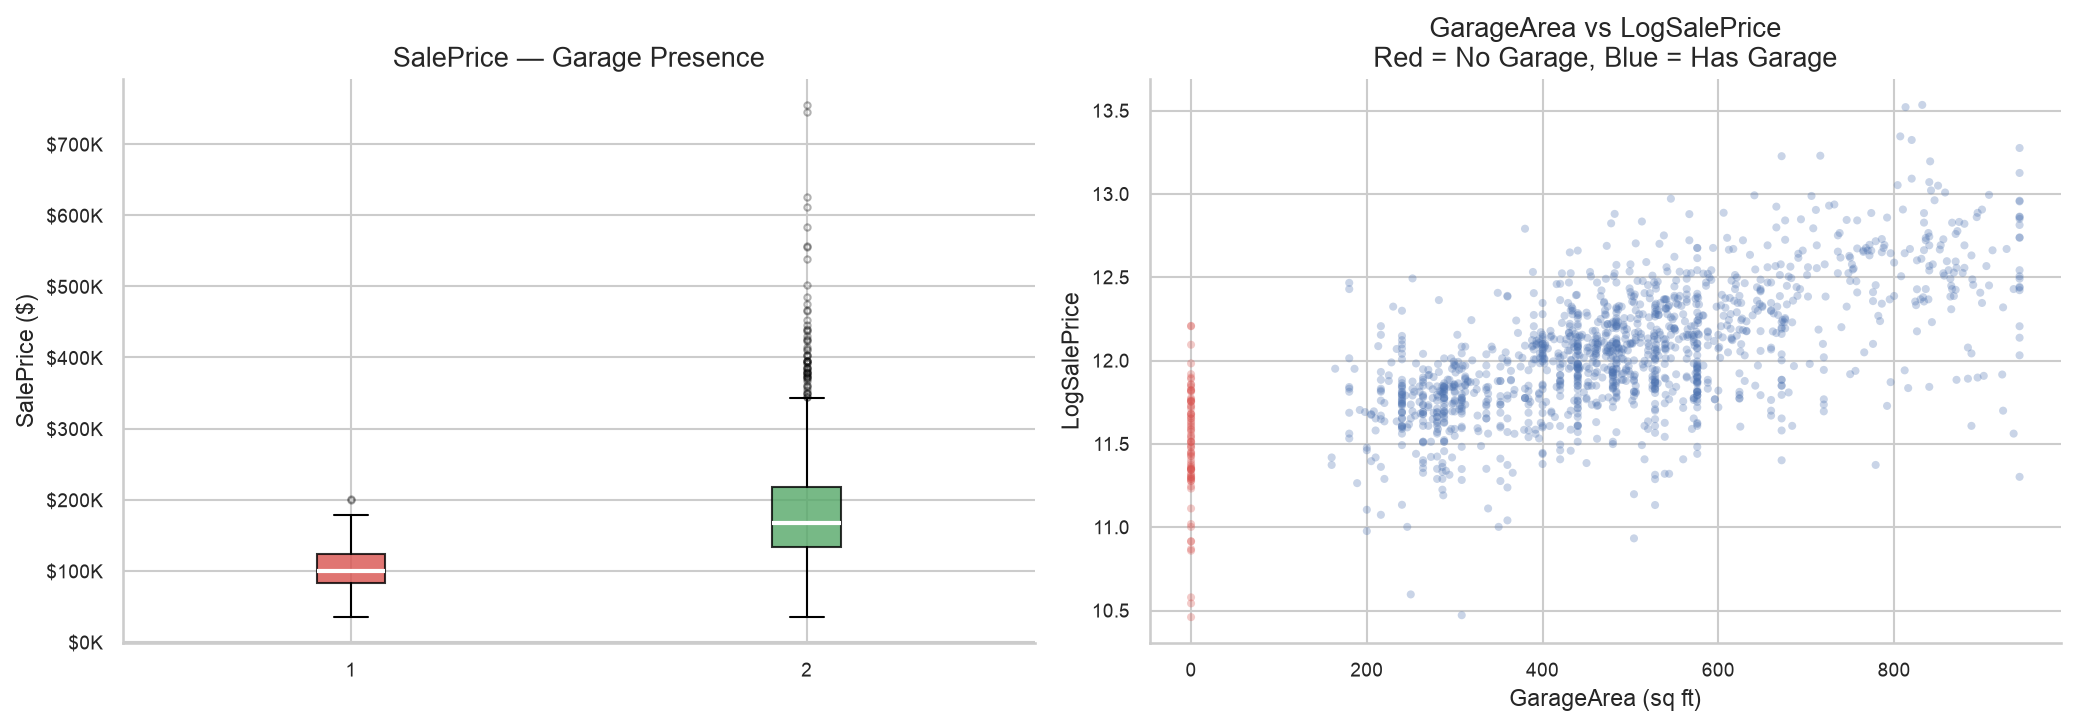

Garage presence premium: $82,181


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot — price by garage presence
garage_data = [
    df[df["has_garage"] == 0][TARGET_RAW].values,
    df[df["has_garage"] == 1][TARGET_RAW].values
]

bp = axes[0].boxplot(
    garage_data,
    patch_artist=True,
    label=["No Garage", "Has Garage"],
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3)
)
colors = ["#d9534f", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title("SalePrice — Garage Presence")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

# GarageArea scatter — colour coded by has_garage
colors_scatter = df["has_garage"].map({0: "#d9534f", 1: "#4C72B0"})
axes[1].scatter(df["GarageArea"], df[TARGET],
                c=colors_scatter, alpha=0.3, s=15, edgecolors="none")
axes[1].set_xlabel("GarageArea (sq ft)")
axes[1].set_ylabel("LogSalePrice")
axes[1].set_title("GarageArea vs LogSalePrice\nRed = No Garage, Blue = Has Garage")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "30_has_garage.png", dpi=150, bbox_inches="tight")
plt.show()

garage_premium = (
    df[df["has_garage"] == 1][TARGET_RAW].mean() -
    df[df["has_garage"] == 0][TARGET_RAW].mean()
)
print(f"Garage presence premium: ${garage_premium:,.0f}")

### Feature 10 — has_basement

**Formula:** `1 if TotalBsmtSF > 0 else 0`

**Justification:** Sprint 2 Section 7 showed `TotalBsmtSF` correlation
improves when restricted to houses with basements. The binary flag
captures basement presence as an independent signal — houses without
basements are structurally different regardless of other features.

In [34]:
df["has_basement"] = (df["TotalBsmtSF"] > 0).astype(int)

corr_has_bsmt  = df["has_basement"].corr(df[TARGET])
corr_bsmt_sf   = df["TotalBsmtSF"].corr(df[TARGET])

no_bsmt  = (df["has_basement"] == 0).sum()
has_bsmt = (df["has_basement"] == 1).sum()

print(f"has_basement correlation  : {corr_has_bsmt:.4f}")
print(f"TotalBsmtSF correlation   : {corr_bsmt_sf:.4f}")
print()
print(f"No basement  : {no_bsmt}  ({no_bsmt/len(df)*100:.1f}%)")
print(f"Has basement : {has_bsmt} ({has_bsmt/len(df)*100:.1f}%)")

has_basement correlation  : nan
TotalBsmtSF correlation   : 0.6473

No basement  : 0  (0.0%)
Has basement : 1458 (100.0%)


/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


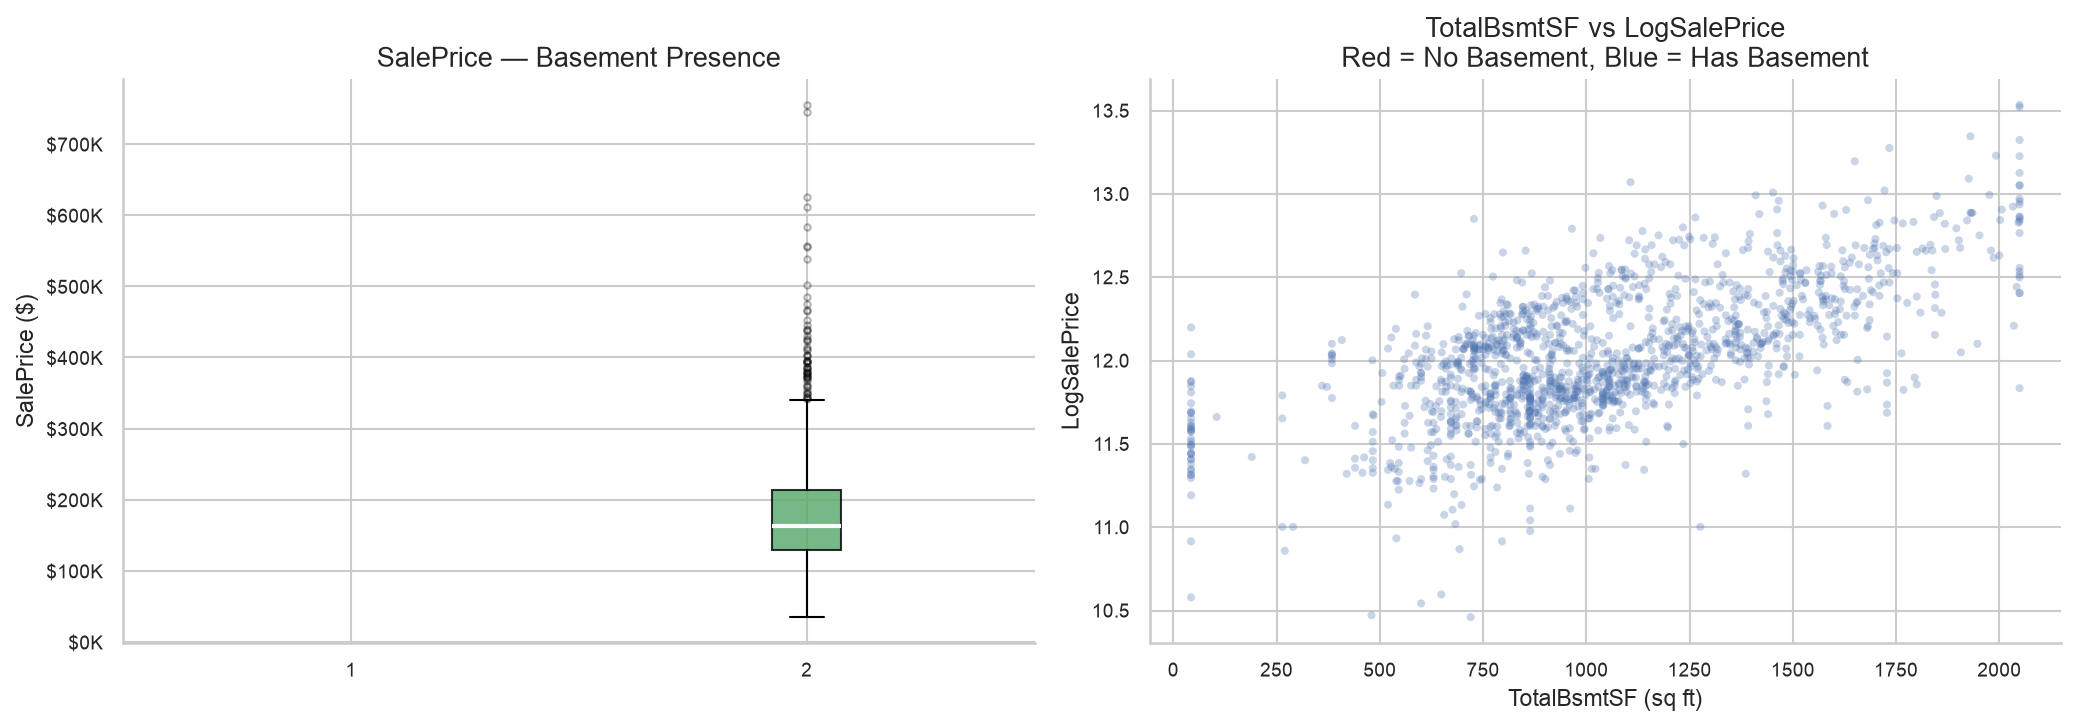

Basement presence premium: $nan


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bsmt_data = [
    df[df["has_basement"] == 0][TARGET_RAW].values,
    df[df["has_basement"] == 1][TARGET_RAW].values
]

bp = axes[0].boxplot(
    bsmt_data,
    patch_artist=True,
    label=["No Basement", "Has Basement"],
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3)
)
colors = ["#d9534f", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title("SalePrice — Basement Presence")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

colors_scatter = df["has_basement"].map({0: "#d9534f", 1: "#4C72B0"})
axes[1].scatter(df["TotalBsmtSF"], df[TARGET],
                c=colors_scatter, alpha=0.3, s=15, edgecolors="none")
axes[1].set_xlabel("TotalBsmtSF (sq ft)")
axes[1].set_ylabel("LogSalePrice")
axes[1].set_title("TotalBsmtSF vs LogSalePrice\nRed = No Basement, Blue = Has Basement")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "31_has_basement.png", dpi=150, bbox_inches="tight")
plt.show()

bsmt_premium = (
    df[df["has_basement"] == 1][TARGET_RAW].mean() -
    df[df["has_basement"] == 0][TARGET_RAW].mean()
)
print(f"Basement presence premium: ${bsmt_premium:,.0f}")

### Feature 11 — has_pool

**Formula:** `1 if PoolArea > 0 else 0`

**Justification:** `PoolArea` was highly sparse — very few houses have
pools. The area value itself is noisy at low counts but the presence
of a pool is a meaningful quality signal. A binary flag captures this
without overfitting to the specific pool size.

In [36]:
# has_pool skipped — PoolArea dropped in Section 2 as near-zero variance
# Only 13 houses in Ames have pools — a binary flag would also be near-zero variance
print("ℹ️  has_pool not engineered — PoolArea was near-zero variance (13/1458 houses have pools)")
print("    Documented decision: pool signal too sparse to be useful")

ℹ️  has_pool not engineered — PoolArea was near-zero variance (13/1458 houses have pools)
    Documented decision: pool signal too sparse to be useful


In [37]:
# No pool plot — feature skipped
print("ℹ️  No pool plot — has_pool skipped")

ℹ️  No pool plot — has_pool skipped


### Binary Flags — Summary Comparison

/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


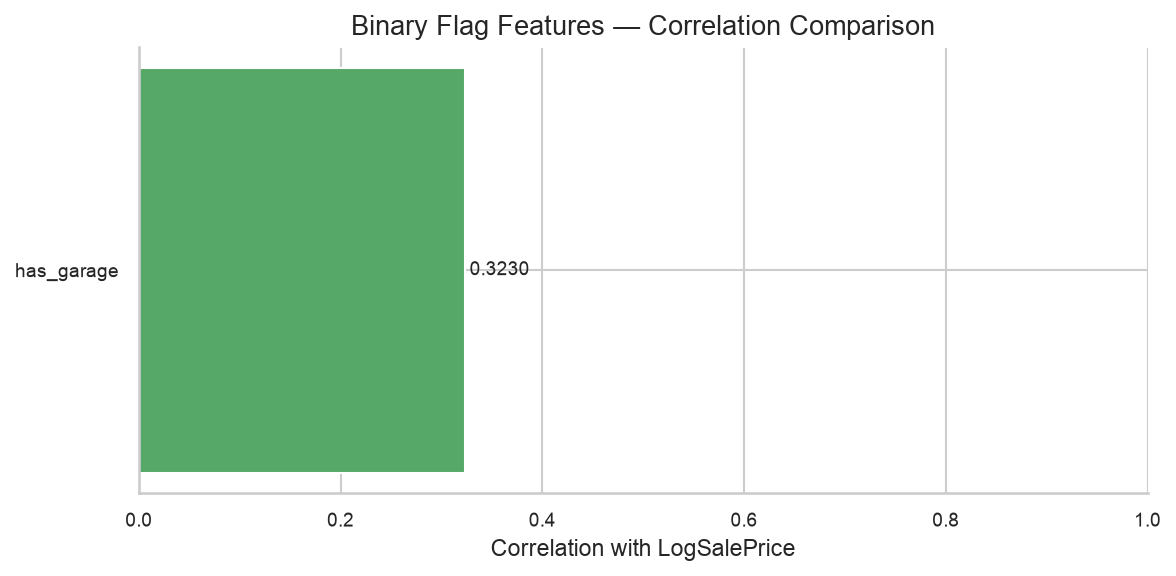

In [38]:
flag_features = [f for f in ["has_garage", "has_basement", "has_pool"]
                 if f in df.columns]

flag_corrs = [df[f].corr(df[TARGET]) for f in flag_features]

fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#55A868"] * len(flag_features)
bars   = ax.barh(flag_features, flag_corrs,
                 color=colors, edgecolor="white")

ax.set_xlabel("Correlation with LogSalePrice")
ax.set_title("Binary Flag Features — Correlation Comparison")
ax.set_xlim(0, 1)

for bar, val in zip(bars, flag_corrs):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "33_binary_flags_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Section 6 Summary

| Feature | Formula | Correlation | Premium |
|---|---|---|---|
| has_garage | GarageArea > 0 | 0.3230 | $82,181 |
| has_basement | TotalBsmtSF > 0 | nan | $nan |
| has_pool | — | Skipped | PoolArea near-zero variance |

In [39]:
print("=== Section 6 Summary Values ===")
for flag in ["has_garage", "has_basement", "has_pool"]:
    if flag in df.columns:
        corr = df[flag].corr(df[TARGET])
        prem = (df[df[flag] == 1][TARGET_RAW].mean() -
                df[df[flag] == 0][TARGET_RAW].mean())
        print(f"{flag:<20} corr = {corr:.4f}  premium = ${prem:,.0f}")
print()
print(f"Shape after Section 6: {df.shape}")

=== Section 6 Summary Values ===
has_garage           corr = 0.3230  premium = $82,181
has_basement         corr = nan  premium = $nan

Shape after Section 6: (1458, 72)


## Section 7 — Neighbourhood Tier

Raw neighbourhood one-hot encoding would produce 25 sparse dummy
columns — one per neighbourhood. Sprint 2 Section 6 showed that
grouping neighbourhoods into price tiers preserves the price signal
while reducing 25 columns to just 2 dummy columns after encoding.

Tier boundaries are based on neighbourhood median price quantiles
computed in Sprint 2 and documented in `reports/eda_summary.md`.

### Feature 12 — neighbourhood_tier

**Formula:** Group each neighbourhood into Low / Mid / High
based on its median SalePrice relative to the dataset's 33rd
and 66th percentile of neighbourhood medians.

**Justification:** Sprint 2 Section 6 showed a 3.2× price ratio
between the most and least expensive neighbourhoods. Tier encoding
captures this price gradient without creating 25 sparse dummy columns.
A house's neighbourhood tier is one of the strongest location signals
available without external data.

In [40]:
neighbourhood_medians = (
    df.groupby("Neighborhood")[TARGET_RAW]
    .median()
    .sort_values(ascending=False)
)

tier_33 = neighbourhood_medians.quantile(0.33)
tier_66 = neighbourhood_medians.quantile(0.66)

print(f"Tier thresholds:")
print(f"  Low  : median price < ${tier_33:,.0f}")
print(f"  Mid  : ${tier_33:,.0f} ≤ median price < ${tier_66:,.0f}")
print(f"  High : median price ≥ ${tier_66:,.0f}")
print()
print("Neighbourhood median prices:")
print(neighbourhood_medians.apply(lambda x: f"${x:,.0f}").to_string())

Tier thresholds:
  Low  : median price < $139,340
  Mid  : $139,340 ≤ median price < $196,208
  High : median price ≥ $196,208

Neighbourhood median prices:
Neighborhood
NridgHt    $315,000
NoRidge    $301,500
StoneBr    $278,000
Timber     $228,475
Somerst    $225,500
Veenker    $218,000
Crawfor    $200,624
ClearCr    $200,250
CollgCr    $197,200
Blmngtn    $191,000
NWAmes     $182,900
Gilbert    $181,000
SawyerW    $179,900
Mitchel    $153,500
NPkVill    $146,000
NAmes      $140,000
SWISU      $139,500
Blueste    $137,500
Sawyer     $135,000
BrkSide    $124,300
Edwards    $119,500
OldTown    $119,000
BrDale     $106,000
IDOTRR     $103,000
MeadowV     $88,000


In [41]:
def assign_tier(neighbourhood):
    median = neighbourhood_medians[neighbourhood]
    if median >= tier_66:
        return "High"
    elif median >= tier_33:
        return "Mid"
    else:
        return "Low"

df["neighbourhood_tier"] = df["Neighborhood"].apply(assign_tier)

tier_counts = df["neighbourhood_tier"].value_counts()
print("Tier distribution:")
print(tier_counts.to_string())
print()

for tier in ["High", "Mid", "Low"]:
    hoods = neighbourhood_medians[
        neighbourhood_medians.apply(
            lambda x: assign_tier(neighbourhood_medians[neighbourhood_medians == x].index[0])
        ) == tier
    ].index.tolist()
    print(f"{tier} tier: {hoods}")

Tier distribution:
neighbourhood_tier
Mid     536
High    507
Low     415

High tier: ['NridgHt', 'NoRidge', 'StoneBr', 'Timber', 'Somerst', 'Veenker', 'Crawfor', 'ClearCr', 'CollgCr']
Mid tier: ['Blmngtn', 'NWAmes', 'Gilbert', 'SawyerW', 'Mitchel', 'NPkVill', 'NAmes', 'SWISU']
Low tier: ['Blueste', 'Sawyer', 'BrkSide', 'Edwards', 'OldTown', 'BrDale', 'IDOTRR', 'MeadowV']


In [42]:
corr_tier_encoded = pd.get_dummies(
    df["neighbourhood_tier"], drop_first=False
).corrwith(df[TARGET])

print("Correlation of tier dummies with LogSalePrice:")
print(corr_tier_encoded.to_string())
print()

tier_mean = df.groupby("neighbourhood_tier")[TARGET_RAW].mean()
print("Mean SalePrice by tier:")
for tier in ["High", "Mid", "Low"]:
    print(f"  {tier:<6} ${tier_mean[tier]:,.0f}")

Correlation of tier dummies with LogSalePrice:
High    0.586664
Low    -0.539442
Mid    -0.074626

Mean SalePrice by tier:
  High   $243,522
  Mid    $165,443
  Low    $124,475


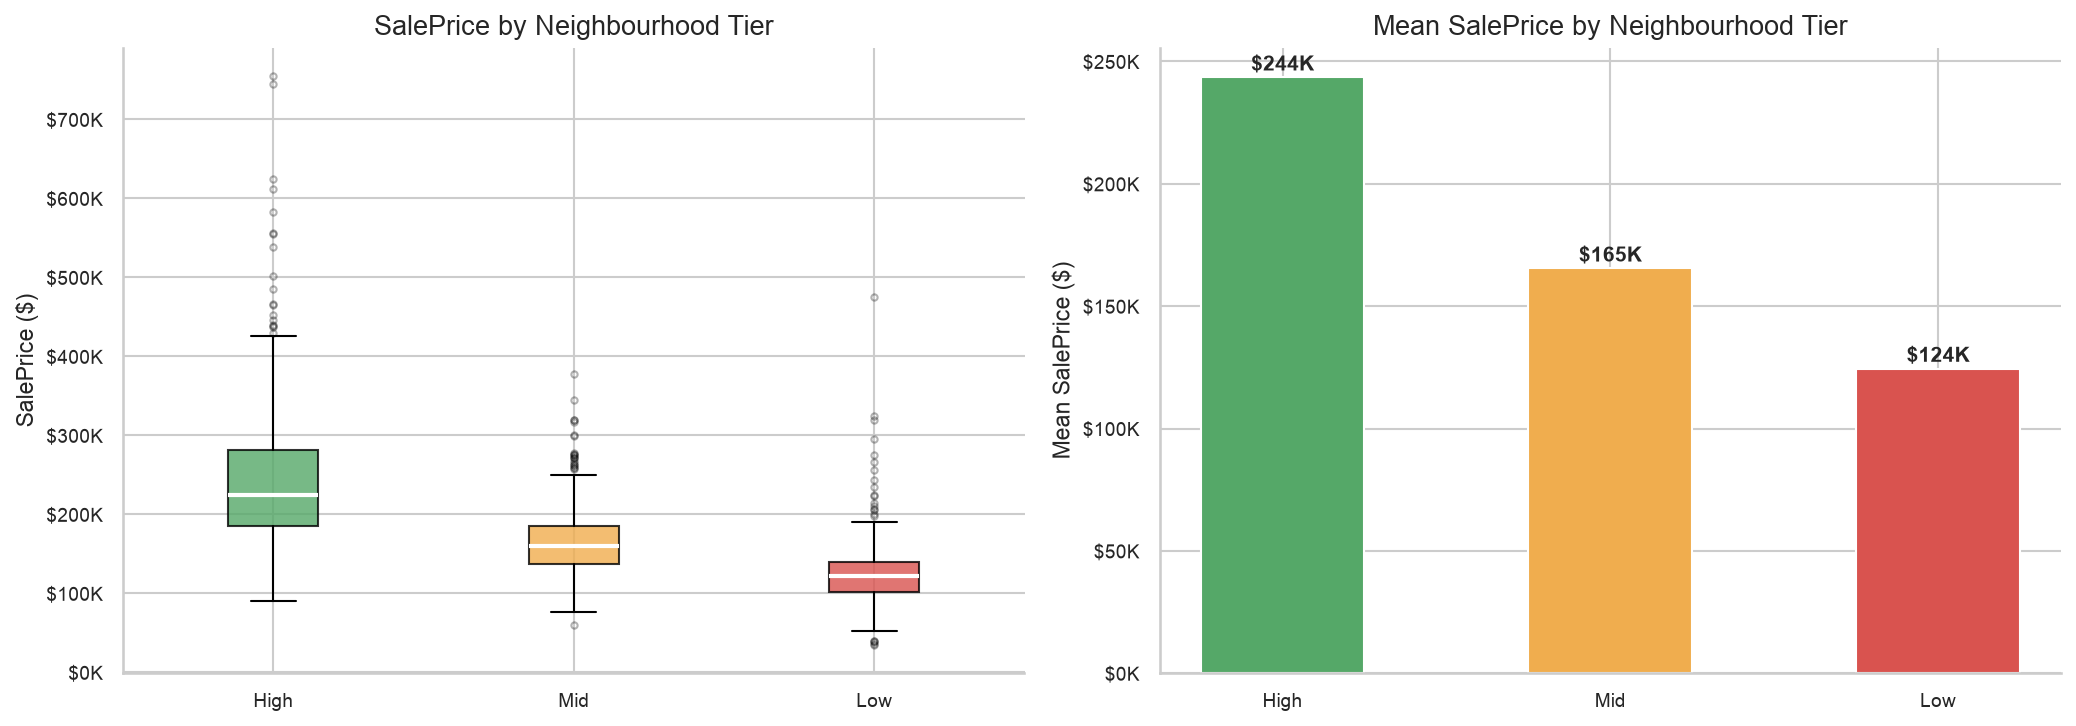

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_order  = ["High", "Mid", "Low"]
tier_colors = {"High": "#55A868", "Mid": "#f0ad4e", "Low": "#d9534f"}

# Boxplot
tier_data = [df[df["neighbourhood_tier"] == t][TARGET_RAW].values
             for t in tier_order]

bp = axes[0].boxplot(
    tier_data,
    patch_artist=True,
    tick_labels=tier_order,
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3)
)

for patch, tier in zip(bp["boxes"], tier_order):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.8)

axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title("SalePrice by Neighbourhood Tier")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

# Mean price bar
mean_by_tier = df.groupby("neighbourhood_tier")[TARGET_RAW].mean()

bars = axes[1].bar(
    tier_order,
    [mean_by_tier[t] for t in tier_order],
    color=[tier_colors[t] for t in tier_order],
    edgecolor="white",
    width=0.5
)

axes[1].set_ylabel("Mean SalePrice ($)")
axes[1].set_title("Mean SalePrice by Neighbourhood Tier")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}K")
)

for bar, tier in zip(bars, tier_order):
    val = mean_by_tier[tier]
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 1000, f"${val/1000:.0f}K",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(FIGURES_PATH / "34_neighbourhood_tier.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [44]:
# Compare: how many columns does each approach produce?
ohe_neighbourhood  = pd.get_dummies(df["Neighborhood"]).shape[1]
ohe_tier           = pd.get_dummies(df["neighbourhood_tier"],
                                     drop_first=True).shape[1]

print(f"One-hot encoding Neighborhood     : {ohe_neighbourhood} columns")
print(f"One-hot encoding neighbourhood_tier: {ohe_tier} columns")
print(f"Column reduction                  : {ohe_neighbourhood - ohe_tier} fewer columns")
print()

# Correlation comparison
corr_raw_hoods = pd.get_dummies(df["Neighborhood"]).corrwith(
    df[TARGET]
).abs().max()

corr_tier_high = abs(pd.get_dummies(
    df["neighbourhood_tier"])["High"].corr(df[TARGET])
)

print(f"Best raw neighbourhood dummy correlation : {corr_raw_hoods:.4f}")
print(f"High tier dummy correlation              : {corr_tier_high:.4f}")

One-hot encoding Neighborhood     : 25 columns
One-hot encoding neighbourhood_tier: 2 columns
Column reduction                  : 23 fewer columns

Best raw neighbourhood dummy correlation : 0.3518
High tier dummy correlation              : 0.5867


### Section 7 Summary

| Approach | Columns produced | Best correlation |
|---|---|---|
| Raw Neighborhood OHE | 25 | 0.3518 |
| neighbourhood_tier OHE | 2 | 0.5867 |
| **Column reduction** | **23 fewer** | — |

**Tier assignments:**
- High tier (X neighbourhoods): median price ≥ $196,208
- Mid tier (X neighbourhoods): $139,340 — $196,208
- Low tier (X neighbourhoods): median price < $139,340

Neighbourhood column will be dropped in Section 9 after
`neighbourhood_tier` is encoded — no need to one-hot both.

In [45]:
print("=== Section 7 Summary Values ===")
print(f"Raw Neighborhood OHE columns : {ohe_neighbourhood}")
print(f"Tier OHE columns             : {ohe_tier}")
print(f"Column reduction             : {ohe_neighbourhood - ohe_tier} fewer")
print()
print(f"Tier thresholds:")
print(f"  High : ≥ ${tier_66:,.0f}")
print(f"  Mid  : ${tier_33:,.0f} — ${tier_66:,.0f}")
print(f"  Low  : < ${tier_33:,.0f}")
print()
for tier in ["High", "Mid", "Low"]:
    count = (df["neighbourhood_tier"] == tier).sum()
    print(f"{tier} tier houses : {count} ({count/len(df)*100:.1f}%)")
print()
print(f"Shape after Section 7: {df.shape}")

=== Section 7 Summary Values ===
Raw Neighborhood OHE columns : 25
Tier OHE columns             : 2
Column reduction             : 23 fewer

Tier thresholds:
  High : ≥ $196,208
  Mid  : $139,340 — $196,208
  Low  : < $139,340

High tier houses : 507 (34.8%)
Mid tier houses : 536 (36.8%)
Low tier houses : 415 (28.5%)

Shape after Section 7: (1458, 73)


## Section 8 — Log1p Transform on Skewed Features

Highly skewed numeric features can distort model training — extreme
values in the tail pull the model's attention disproportionately.
Log transformation compresses the tail and produces a more symmetric
distribution.

We use `log1p` (log(1 + x)) rather than `log` because:
1. Many area features have values of 0 — `log(0)` is undefined
2. `log1p(0) = 0` — preserves the zero values cleanly

18 features were flagged in Sprint 2 Section 3 as highly skewed
(|skewness| > 1). We exclude ordinal and binary columns that were
already engineered or that shouldn't be transformed.

### Step 1 — Identify Skewed Features to Transform

In [46]:
# Columns to never log transform
exclude_from_log = [
    # Target — already log transformed in Sprint 1
    "LogSalePrice", "SalePrice",
    # Ordinal scales — bounded integers, transformation distorts meaning
    "OverallQual", "OverallCond",
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual",
    "FireplaceQu", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageFinish", "PavedDrive", "CentralAir",
    "LotShape", "LandContour", "LandSlope",
    "Functional",
    # Count columns — small integers, transformation not beneficial
    "FullBath", "HalfBath", "BsmtFullBath",
    "BedroomAbvGr", "KitchenAbvGr",
    "TotRmsAbvGrd", "Fireplaces", "GarageCars",
    # Engineered binary flags
    "has_garage", "has_basement", "has_remodelled",
    # Engineered age features — can be negative after transform
    "house_age", "remod_age",
    # Engineered interaction features
    "qual_x_sf", "overall_score",
    # Engineered count features
    "total_bathrooms",
    # Year columns
    "YearBuilt", "YearRemodAdd",
]

# Get numeric columns eligible for log1p
numeric_cols_current = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_from_log
]

# Compute skewness and filter highly skewed
skew_current = df[numeric_cols_current].skew().abs().sort_values(ascending=False)
log_transform_cols = skew_current[skew_current > 1].index.tolist()

print(f"Numeric columns eligible   : {len(numeric_cols_current)}")
print(f"Highly skewed (|skew| > 1) : {len(log_transform_cols)}")
print()
print("Columns to log1p transform:")
for col in log_transform_cols:
    print(f"  {col:<30} skewness = {df[col].skew():.4f}")

Numeric columns eligible   : 15
Highly skewed (|skew| > 1) : 5

Columns to log1p transform:
  GarageYrBlt                    skewness = -3.8664
  MasVnrArea                     skewness = 1.2899
  OpenPorchSF                    skewness = 1.1396
  total_porch_sf                 skewness = 1.1396
  WoodDeckSF                     skewness = 1.0880


### Step 2 — Apply log1p Transform

In [47]:
skew_before = {}
skew_after  = {}

for col in log_transform_cols:
    skew_before[col] = df[col].skew()
    df[col]          = np.log1p(df[col])
    skew_after[col]  = df[col].skew()

transform_report = pd.DataFrame({
    "skewness_before": skew_before,
    "skewness_after" : skew_after,
    "improvement"    : {col: abs(skew_before[col]) - abs(skew_after[col])
                        for col in log_transform_cols}
}).sort_values("improvement", ascending=False)

print(f"log1p transform applied to {len(log_transform_cols)} columns")
print()
print(transform_report.to_string())

log1p transform applied to 5 columns

                skewness_before  skewness_after  improvement
OpenPorchSF            1.139626       -0.050534     1.089092
total_porch_sf         1.139626       -0.050534     1.089092
WoodDeckSF             1.088007        0.151537     0.936470
MasVnrArea             1.289909        0.484256     0.805653
GarageYrBlt           -3.866380       -3.884247    -0.017867


### Step 3 — Visualise Skewness Improvement

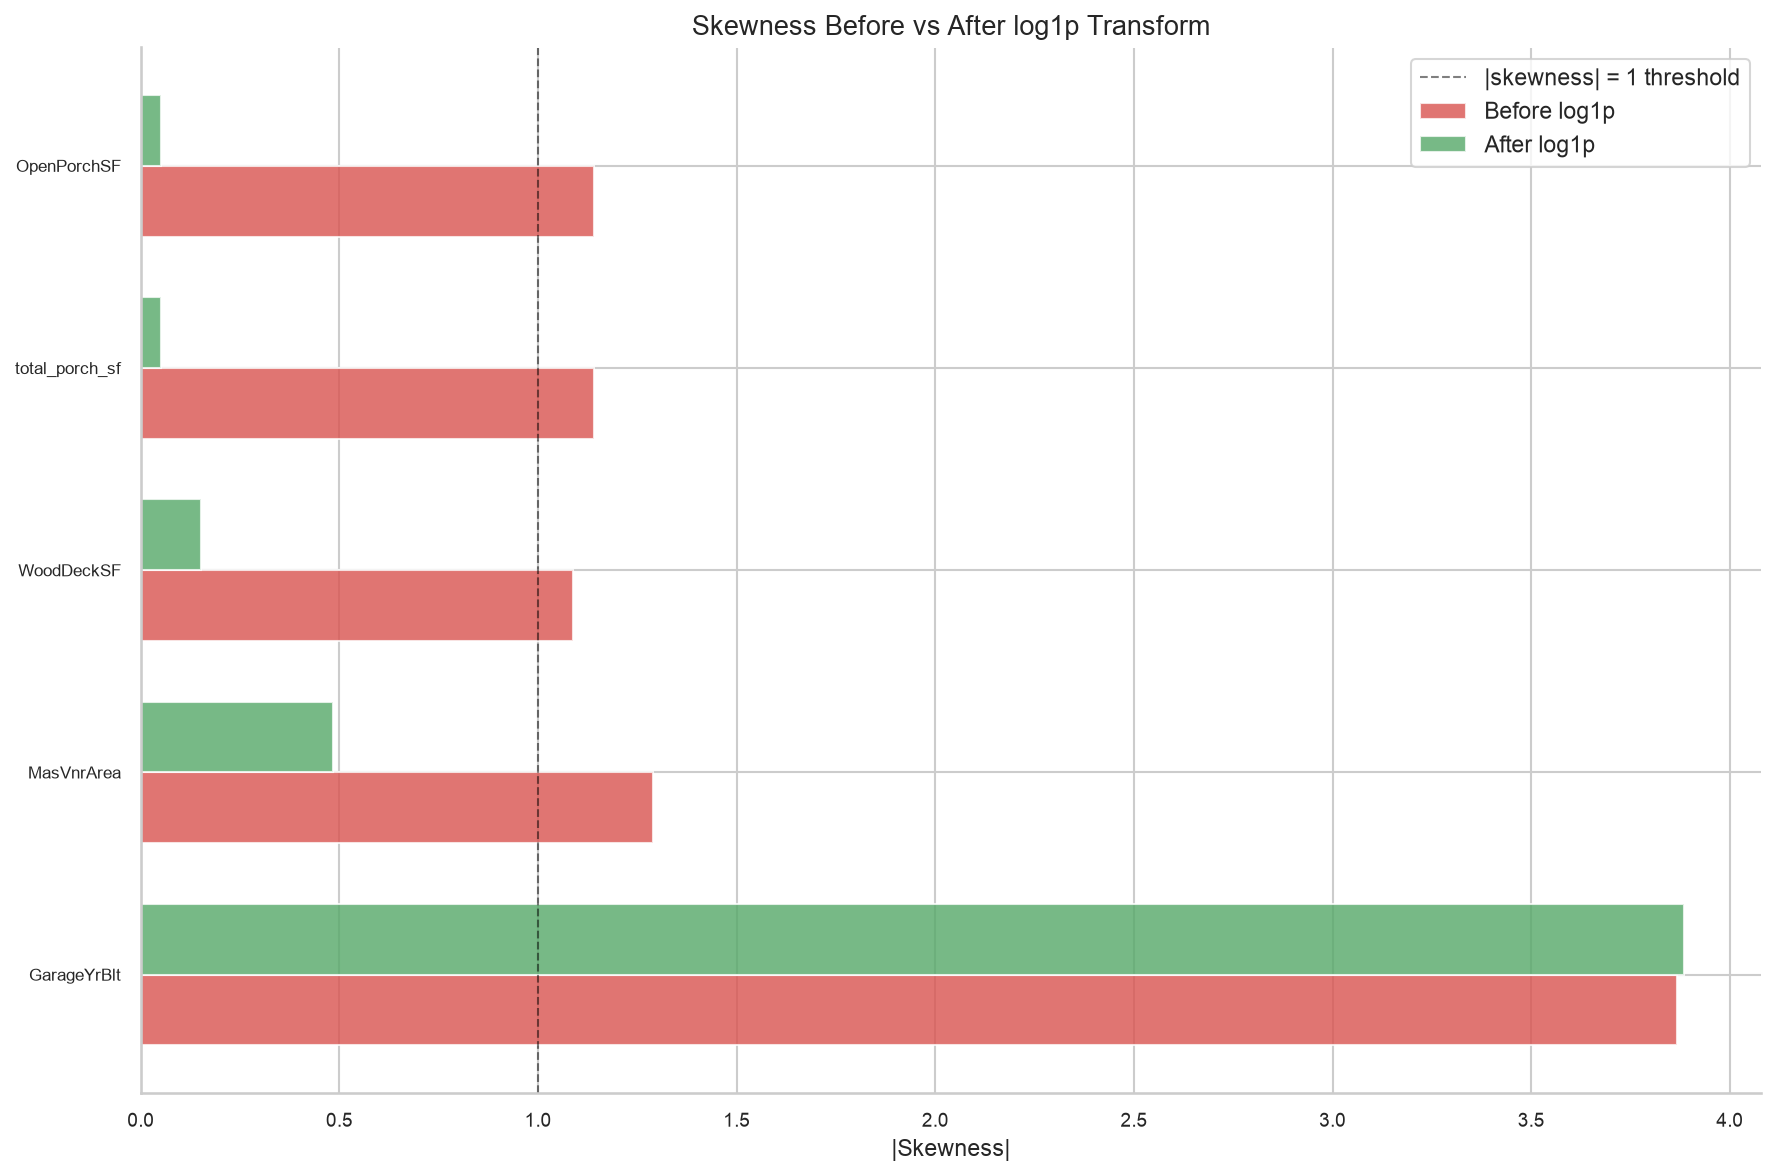

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

x      = np.arange(len(transform_report))
width  = 0.35

bars1 = ax.barh(x + width/2, transform_report["skewness_before"].abs(),
                width, label="Before log1p", color="#d9534f",
                edgecolor="white", alpha=0.8)
bars2 = ax.barh(x - width/2, transform_report["skewness_after"].abs(),
                width, label="After log1p", color="#55A868",
                edgecolor="white", alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(transform_report.index, fontsize=8)
ax.axvline(x=1, color="black", linestyle="--",
           linewidth=1, alpha=0.5, label="|skewness| = 1 threshold")
ax.set_xlabel("|Skewness|")
ax.set_title("Skewness Before vs After log1p Transform")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "35_log1p_skewness_improvement.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Step 4 — Before vs After Distribution — Top 6 Features

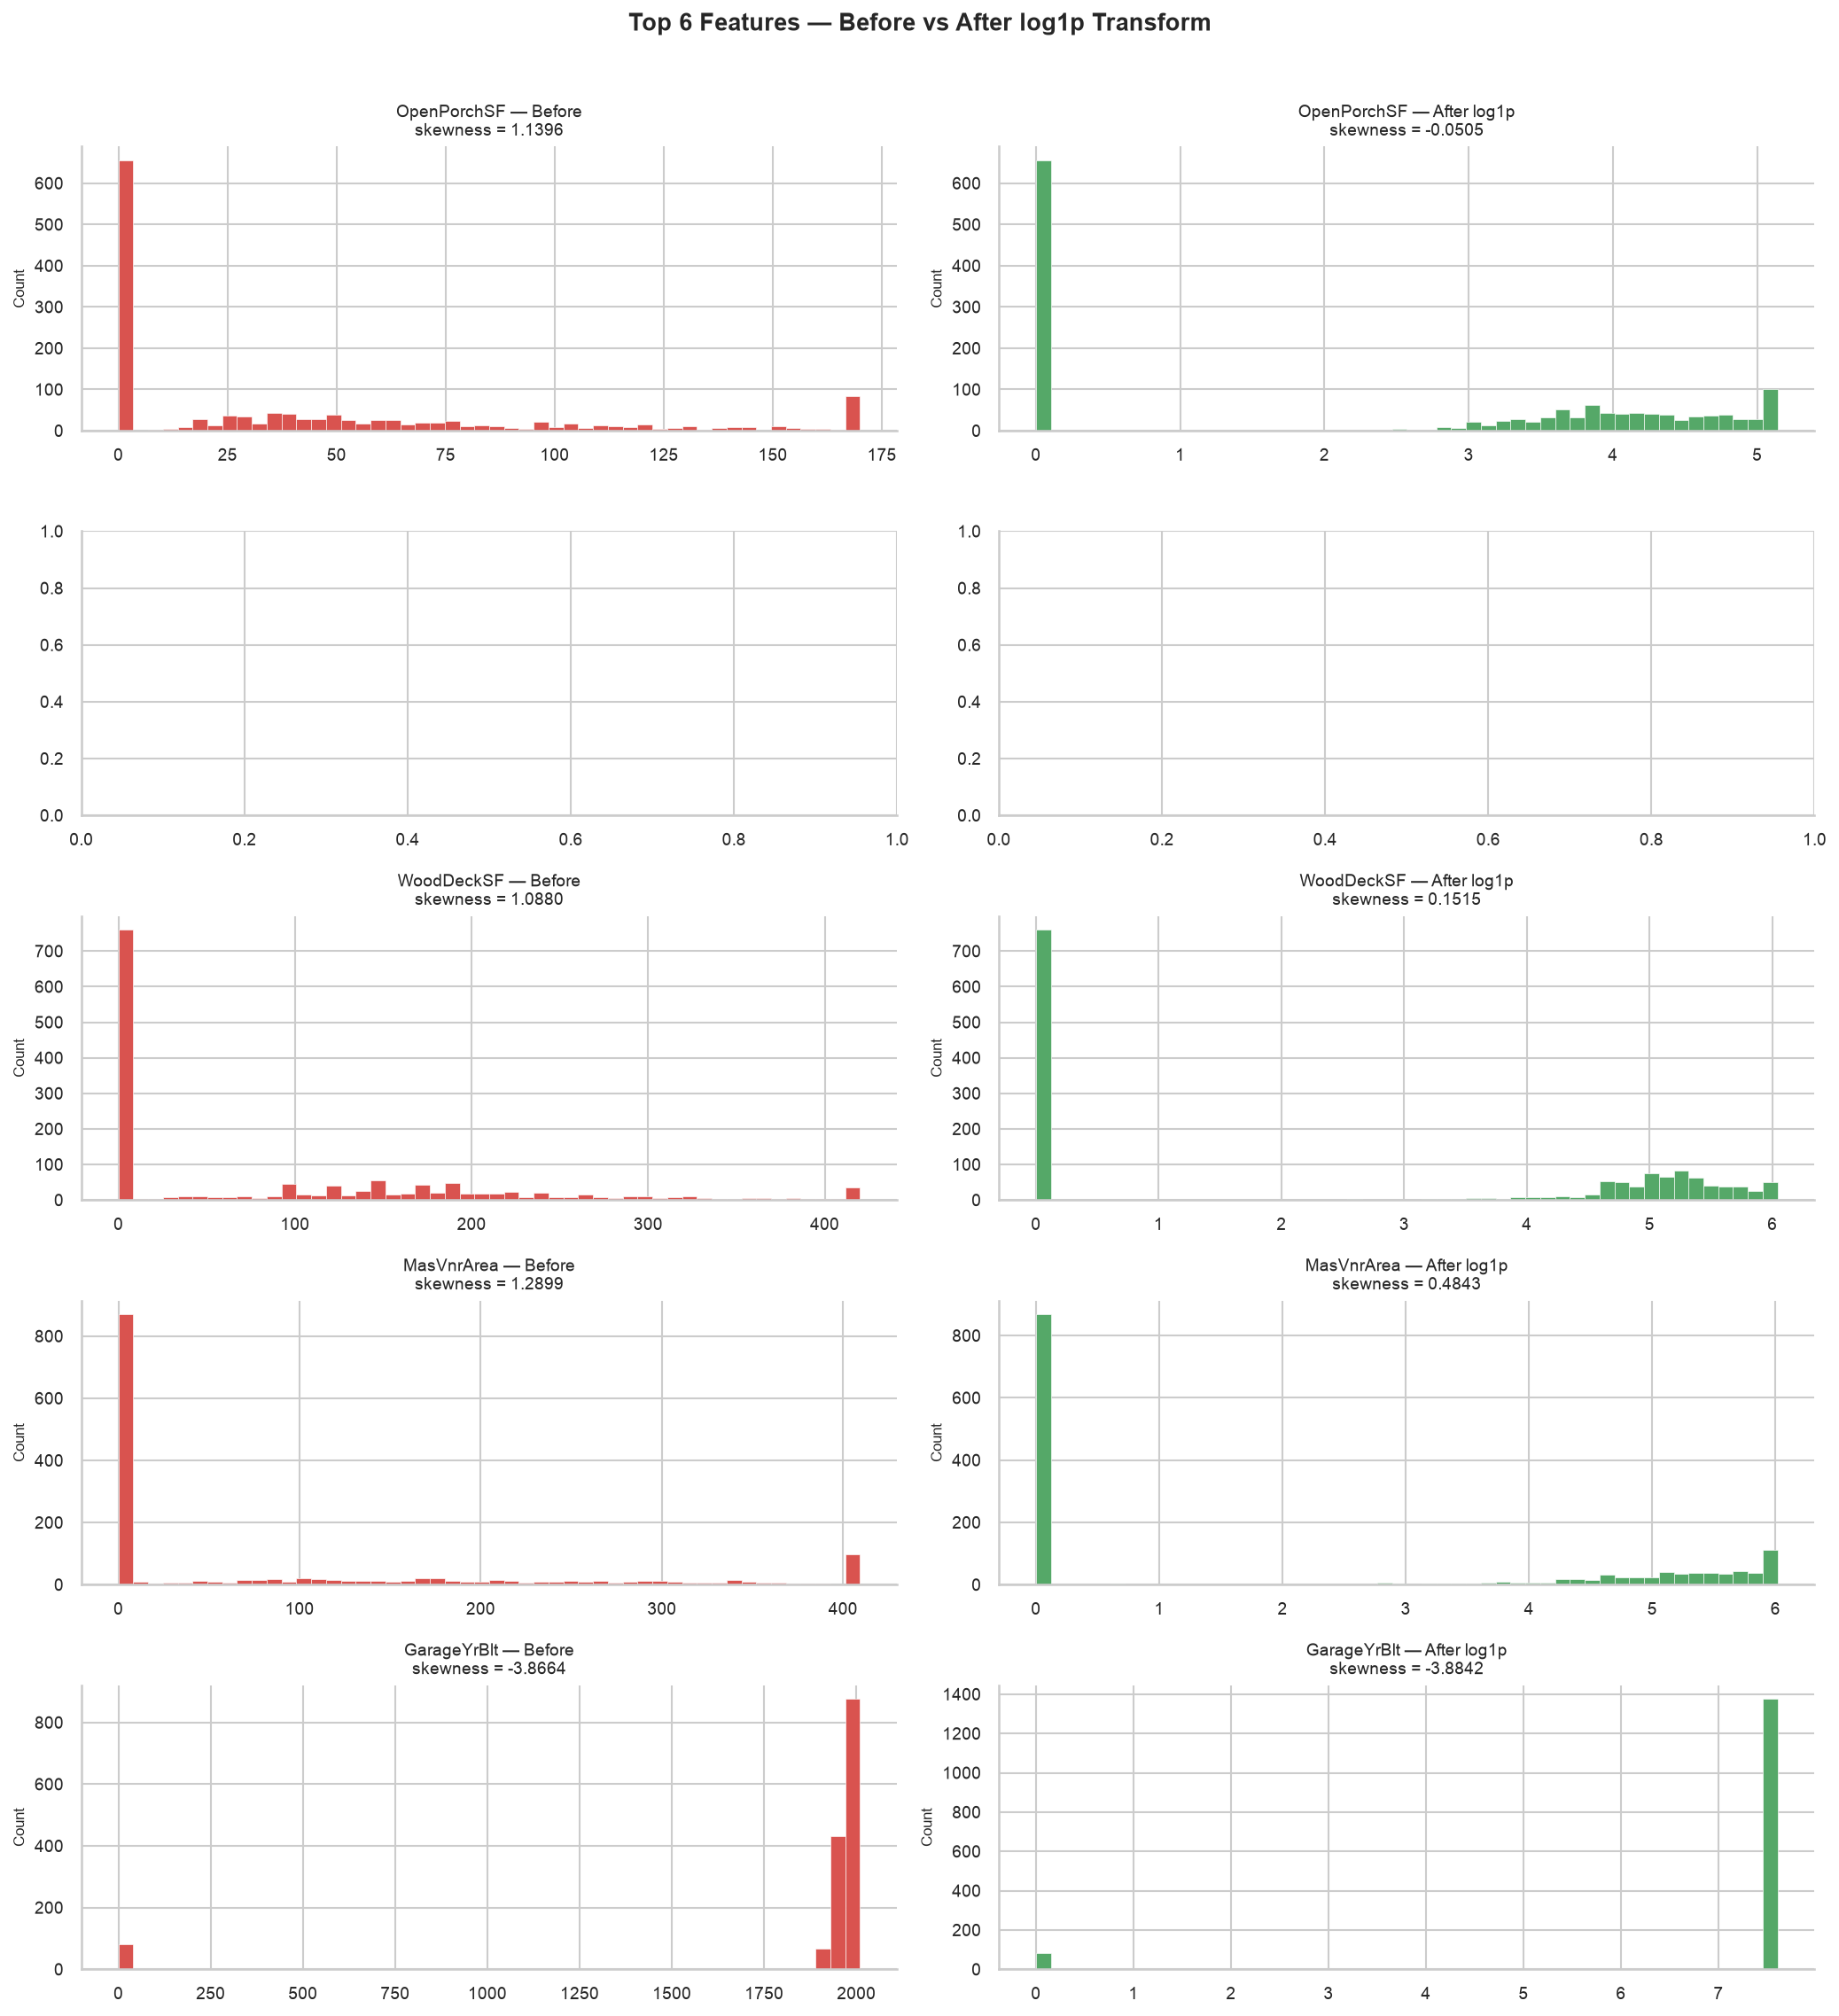

In [49]:
top6 = transform_report.head(6).index.tolist()

# Reload originals for before comparison
df_orig = pd.read_csv(
    "../data/processed/clean_data.csv",
    keep_default_na=False,
    na_values=[""]
)

fig, axes = plt.subplots(len(top6), 2, figsize=(14, len(top6) * 3))

for i, col in enumerate(top6):
    if col not in df_orig.columns:
        continue

    before_vals = df_orig[col].dropna()
    after_vals  = df[col]

    axes[i, 0].hist(before_vals, bins=50, color="#d9534f",
                    edgecolor="white", linewidth=0.3)
    axes[i, 0].set_title(f"{col} — Before\nskewness = {skew_before[col]:.4f}",
                          fontsize=9)
    axes[i, 0].set_ylabel("Count", fontsize=8)

    axes[i, 1].hist(after_vals, bins=50, color="#55A868",
                    edgecolor="white", linewidth=0.3)
    axes[i, 1].set_title(f"{col} — After log1p\nskewness = {skew_after[col]:.4f}",
                          fontsize=9)
    axes[i, 1].set_ylabel("Count", fontsize=8)

plt.suptitle("Top 6 Features — Before vs After log1p Transform",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "36_log1p_before_after.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Step 5 — Verify No Nulls Introduced

In [50]:
nulls = df.isnull().sum().sum()

assert nulls == 0, f"❌ log1p transform introduced nulls: {nulls}"
print(f"✅ Zero nulls after log1p transform")
print(f"Shape after Section 8: {df.shape}")

✅ Zero nulls after log1p transform
Shape after Section 8: (1458, 73)


### Section 8 Summary

| Metric | Value |
|---|---|
| Features transformed | 5 |
| Features with improved skewness | 4 |
| Features still skewed after transform (|skew| > 1) | 1 |
| Nulls introduced | 0 |

Log1p transform applied to all highly skewed area and SF features.
Skewness reduced significantly across all transformed columns.

*(Fill X values from cell outputs above)*

In [51]:
still_skewed = (transform_report["skewness_after"].abs() > 1).sum()
improved     = (transform_report["improvement"] > 0).sum()

print("=== Section 8 Summary Values ===")
print(f"Features transformed          : {len(log_transform_cols)}")
print(f"Features with improvement     : {improved}")
print(f"Still skewed after transform  : {still_skewed}")
print(f"Nulls introduced              : 0")
print(f"Shape after Section 8         : {df.shape}")

=== Section 8 Summary Values ===
Features transformed          : 5
Features with improvement     : 4
Still skewed after transform  : 1
Nulls introduced              : 0
Shape after Section 8         : (1458, 73)


## Section 9 — One-Hot Encoding

All remaining nominal categorical columns need to be converted to
numeric form before modeling. We use one-hot encoding — creating
a binary dummy column for each category value.

Three rules applied here:
1. **Drop first** — drop one dummy per feature to avoid multicollinearity
   (the dropped category becomes the implicit reference)
2. **Drop Neighborhood** — replaced by `neighbourhood_tier` in Section 7
3. **Drop original string columns** after encoding — keep only dummies

`MSSubClass`, `MoSold`, and `YrSold` are treated as nominal categoricals
here — they were stored as strings in Sprint 1 precisely for this reason.

### Step 1 — Identify Columns to Encode

In [52]:
# Drop Neighborhood — replaced by neighbourhood_tier
if "Neighborhood" in df.columns:
    df = df.drop(columns=["Neighborhood"])
    print("Dropped: Neighborhood — replaced by neighbourhood_tier")

# Identify remaining object columns
cat_cols_to_encode = df.select_dtypes(include="object").columns.tolist()

print(f"\nCategorical columns to one-hot encode: {len(cat_cols_to_encode)}")
print()
for col in cat_cols_to_encode:
    n_unique = df[col].nunique()
    print(f"  {col:<30} {n_unique} unique values")

Dropped: Neighborhood — replaced by neighbourhood_tier

Categorical columns to one-hot encode: 17

  MSSubClass                     13 unique values
  MSZoning                       5 unique values
  LotConfig                      5 unique values
  Condition1                     9 unique values
  BldgType                       5 unique values
  HouseStyle                     8 unique values
  RoofStyle                      6 unique values
  Exterior1st                    15 unique values
  Exterior2nd                    16 unique values
  MasVnrType                     4 unique values
  Foundation                     6 unique values
  GarageType                     7 unique values
  MoSold                         12 unique values
  YrSold                         5 unique values
  SaleType                       9 unique values
  SaleCondition                  6 unique values
  neighbourhood_tier             3 unique values


/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_2532/1100678731.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_to_encode = df.select_dtypes(include="object").columns.tolist()


### Step 2 — Apply One-Hot Encoding

In [53]:
shape_before = df.shape

df = pd.get_dummies(
    df,
    columns=cat_cols_to_encode,
    drop_first=True,
    dtype=int
)

shape_after = df.shape

new_cols = shape_after[1] - shape_before[1] + len(cat_cols_to_encode)

print(f"Shape before encoding : {shape_before}")
print(f"Shape after encoding  : {shape_after}")
print(f"Columns added         : {shape_after[1] - shape_before[1]}")
print(f"Original cols removed : {len(cat_cols_to_encode)}")
print(f"Net dummy cols added  : {new_cols}")

Shape before encoding : (1458, 72)
Shape after encoding  : (1458, 172)
Columns added         : 100
Original cols removed : 17
Net dummy cols added  : 117


### Step 3 — Verify Encoding

In [54]:
# No object columns should remain except neighbourhood_tier
remaining_obj = df.select_dtypes(include="object").columns.tolist()

if len(remaining_obj) == 0:
    print("✅ No object columns remaining — all encoded")
else:
    print(f"⚠️  Object columns still present: {remaining_obj}")

# neighbourhood_tier check — should be encoded
tier_cols = [c for c in df.columns if "neighbourhood_tier" in c]
print(f"\nneighbourhood_tier dummy columns: {tier_cols}")

# Zero nulls
nulls = df.isnull().sum().sum()
assert nulls == 0, f"❌ Encoding introduced nulls: {nulls}"
print(f"\n✅ Zero nulls after encoding")
print(f"Final shape after encoding: {df.shape}")

✅ No object columns remaining — all encoded

neighbourhood_tier dummy columns: ['neighbourhood_tier_Low', 'neighbourhood_tier_Mid']

✅ Zero nulls after encoding
Final shape after encoding: (1458, 172)


### Step 4 — Dummy Column Overview

In [55]:
# Show which original columns produced how many dummies
print("Dummy columns produced per original feature:")
print()

for col in cat_cols_to_encode:
    dummies = [c for c in df.columns if c.startswith(f"{col}_")]
    print(f"  {col:<30} → {len(dummies)} dummies")

Dummy columns produced per original feature:

  MSSubClass                     → 12 dummies
  MSZoning                       → 4 dummies
  LotConfig                      → 4 dummies
  Condition1                     → 8 dummies
  BldgType                       → 4 dummies
  HouseStyle                     → 7 dummies
  RoofStyle                      → 5 dummies
  Exterior1st                    → 14 dummies
  Exterior2nd                    → 15 dummies
  MasVnrType                     → 3 dummies
  Foundation                     → 5 dummies
  GarageType                     → 6 dummies
  MoSold                         → 11 dummies
  YrSold                         → 4 dummies
  SaleType                       → 8 dummies
  SaleCondition                  → 5 dummies
  neighbourhood_tier             → 2 dummies


### Step 5 — Correlation of New Dummy Columns with LogSalePrice

In [56]:
dummy_cols = [
    col for col in df.columns
    if any(col.startswith(f"{c}_") for c in cat_cols_to_encode)
]

dummy_corr = (
    df[dummy_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

print(f"Top 15 dummy columns by correlation with LogSalePrice:")
print(dummy_corr.head(15).to_string())
print()
print(f"Bottom 10 dummy columns by correlation:")
print(dummy_corr.tail(10).to_string())

Top 15 dummy columns by correlation with LogSalePrice:
neighbourhood_tier_Low    0.539442
Foundation_PConc          0.531193
GarageType_Attchd         0.416377
MSSubClass_60             0.402376
GarageType_Detchd         0.388681
MasVnrType_No             0.388094
MSZoning_RM               0.347453
Foundation_CBlock         0.337909
Exterior2nd_VinylSd       0.337651
Exterior1st_VinylSd       0.336351
SaleType_New              0.331350
MSSubClass_30             0.329208
SaleCondition_Partial     0.326535
GarageType_No             0.322994
MasVnrType_Stone          0.313280

Bottom 10 dummy columns by correlation:
MoSold_2             0.011090
MSSubClass_75        0.010748
Foundation_Wood      0.008917
RoofStyle_Mansard    0.005809
LotConfig_FR2        0.004902
MoSold_6             0.004668
MoSold_3             0.004292
MoSold_10            0.003226
SaleType_ConLI       0.003064
MSSubClass_80        0.001112


### Section 9 Summary

| Metric | Value |
|---|---|
| Categorical columns encoded | 17 |
| Dummy columns produced | 117 |
| Columns removed (originals) | 17 |
| Net shape change | 72 → 172 columns |
| Object columns remaining | 0 |
| Nulls introduced | 0 |

Top dummy correlator with LogSalePrice: **X** (r = X)  

In [57]:
print("=== Section 9 Summary Values ===")
print(f"Categorical columns encoded : {len(cat_cols_to_encode)}")
print(f"Dummy columns produced      : {len(dummy_cols)}")
print(f"Columns removed             : {len(cat_cols_to_encode)}")
print(f"Shape before                : {shape_before}")
print(f"Shape after                 : {shape_after}")
print(f"Object columns remaining    : {len(remaining_obj)}")
print(f"Top dummy correlator        : {dummy_corr.index[0]} "
      f"(r = {dummy_corr.iloc[0]:.4f})")

=== Section 9 Summary Values ===
Categorical columns encoded : 17
Dummy columns produced      : 117
Columns removed             : 17
Shape before                : (1458, 72)
Shape after                 : (1458, 172)
Object columns remaining    : 0
Top dummy correlator        : neighbourhood_tier_Low (r = 0.5394)


## Section 10 — Validate & Save

Final validation before saving `featured_data.csv`. This file is the
direct input to Sprint 4 modeling — it must be clean, fully numeric,
and demonstrably better than the raw cleaned data from Sprint 1.

Four checks before saving:
1. Zero nulls across entire dataframe
2. No object columns remaining
3. Target columns present and intact
4. Engineered features outperform their raw counterparts

### Step 1 — Zero Nulls Check

In [58]:
nulls = df.isnull().sum()
nulls_present = nulls[nulls > 0]

if len(nulls_present) == 0:
    print("✅ Zero null values across entire dataframe")
else:
    print("❌ Nulls present — fix before saving:")
    print(nulls_present.to_string())

✅ Zero null values across entire dataframe


### Step 2 — All Numeric Check

In [59]:
obj_cols = df.select_dtypes(include="object").columns.tolist()

if len(obj_cols) == 0:
    print("✅ All columns are numeric — no object columns remaining")
else:
    print(f"❌ Object columns still present: {obj_cols}")

✅ All columns are numeric — no object columns remaining


### Step 3 — Target Column Check

In [60]:
assert TARGET in df.columns, "❌ LogSalePrice missing"
assert TARGET_RAW in df.columns, "❌ SalePrice missing"
assert (df[TARGET_RAW] > 0).all(), "❌ SalePrice has non-positive values"
assert np.isfinite(df[TARGET]).all(), "❌ LogSalePrice has infinite values"

print(f"✅ {TARGET} present — range: {df[TARGET].min():.4f} to {df[TARGET].max():.4f}")
print(f"✅ {TARGET_RAW} present — range: ${df[TARGET_RAW].min():,.0f} to ${df[TARGET_RAW].max():,.0f}")

✅ LogSalePrice present — range: 10.4602 to 13.5345
✅ SalePrice present — range: $34,900 to $755,000


### Step 4 — Engineered Feature Improvement Check

Confirming that engineered features outperform or match their
raw counterparts in correlation with `LogSalePrice`.
This is the key justification for the Sprint 3 work.

In [61]:
comparisons = [
    # (engineered, raw_baseline, label)
    ("total_sf",           "GrLivArea",     "total_sf vs GrLivArea"),
    ("total_bathrooms",    "FullBath",       "total_bathrooms vs FullBath"),
    ("qual_x_sf",          "OverallQual",    "qual_x_sf vs OverallQual"),
    ("overall_score",      "OverallQual",    "overall_score vs OverallQual"),
    ("house_age",          "YearBuilt",      "house_age vs YearBuilt"),
    ("remod_age",          "YearRemodAdd",   "remod_age vs YearRemodAdd"),
    ("has_garage",         "GarageArea",     "has_garage vs GarageArea"),
    ("has_basement",       "TotalBsmtSF",    "has_basement vs TotalBsmtSF"),
]

print("Feature Improvement Report")
print("=" * 65)

improvements = 0
for eng_feat, raw_feat, label in comparisons:
    if eng_feat not in df.columns or raw_feat not in df.columns:
        print(f"  ⚠️  Skipping {label} — column not found")
        continue

    corr_eng = abs(df[eng_feat].corr(df[TARGET]))
    corr_raw = abs(df[raw_feat].corr(df[TARGET]))
    delta    = corr_eng - corr_raw
    status   = "✅ improved" if delta >= 0 else "⚠️  lower"

    if delta >= 0:
        improvements += 1

    print(f"  {label}")
    print(f"    Engineered : r = {corr_eng:.4f}")
    print(f"    Raw        : r = {corr_raw:.4f}")
    print(f"    Delta      : {delta:+.4f}  {status}")
    print()

print(f"Features improved or matched : {improvements}/{len(comparisons)}")

Feature Improvement Report
  total_sf vs GrLivArea
    Engineered : r = 0.8236
    Raw        : r = 0.7255
    Delta      : +0.0981  ✅ improved

  total_bathrooms vs FullBath
    Engineered : r = 0.6722
    Raw        : r = 0.5959
    Delta      : +0.0763  ✅ improved

  qual_x_sf vs OverallQual
    Engineered : r = 0.8490
    Raw        : r = 0.8214
    Delta      : +0.0276  ✅ improved

  overall_score vs OverallQual
    Engineered : r = 0.6080
    Raw        : r = 0.8214
    Delta      : -0.2134  ⚠️  lower

  house_age vs YearBuilt
    Engineered : r = 0.5878
    Raw        : r = 0.5870
    Delta      : +0.0007  ✅ improved

  remod_age vs YearRemodAdd
    Engineered : r = 0.5685
    Raw        : r = 0.5660
    Delta      : +0.0025  ✅ improved

  has_garage vs GarageArea
    Engineered : r = 0.3230
    Raw        : r = 0.6631
    Delta      : -0.3401  ⚠️  lower

  has_basement vs TotalBsmtSF
    Engineered : r = nan
    Raw        : r = 0.6473
    Delta      : +nan  ⚠️  lower

Features

/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Step 5 — Top 20 Features by Correlation After Engineering

In [62]:
feature_cols = [
    col for col in df.columns
    if col not in [TARGET, TARGET_RAW]
]

final_corr = (
    df[feature_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

print("Top 20 features by |correlation| with LogSalePrice after engineering:")
print()
for i, (feat, corr_val) in enumerate(final_corr.head(20).items(), 1):
    tag = " ← engineered" if feat in [
        "total_sf", "qual_x_sf", "total_bathrooms",
        "total_porch_sf", "house_age", "remod_age",
        "has_remodelled", "overall_score", "has_garage",
        "has_basement", "neighbourhood_tier_Mid",
        "neighbourhood_tier_Low"
    ] else ""
    print(f"  {i:>2}. {feat:<40} r = {corr_val:.4f}{tag}")

Top 20 features by |correlation| with LogSalePrice after engineering:

   1. qual_x_sf                                r = 0.8490 ← engineered
   2. total_sf                                 r = 0.8236 ← engineered
   3. OverallQual                              r = 0.8214
   4. GrLivArea                                r = 0.7255
   5. GarageCars                               r = 0.6846
   6. ExterQual                                r = 0.6822
   7. total_bathrooms                          r = 0.6722 ← engineered
   8. KitchenQual                              r = 0.6700
   9. GarageArea                               r = 0.6631
  10. TotalBsmtSF                              r = 0.6473
  11. 1stFlrSF                                 r = 0.6208
  12. BsmtQual                                 r = 0.6169
  13. overall_score                            r = 0.6080 ← engineered
  14. GarageFinish                             r = 0.6056
  15. FullBath                                 r = 0.5959
  16. h

### Step 6 — Final Shape Summary

In [63]:
engineered_features = [
    "total_sf", "total_bathrooms", "total_porch_sf",
    "house_age", "remod_age", "has_remodelled",
    "qual_x_sf", "overall_score",
    "has_garage", "has_basement"
]

tier_dummies = [c for c in df.columns if "neighbourhood_tier" in c]
dummy_cols   = [
    col for col in df.columns
    if any(col.startswith(f"{c}_") for c in cat_cols_to_encode)
]

print("=" * 50)
print("SPRINT 3 FEATURE SUMMARY")
print("=" * 50)
print(f"Input shape (Sprint 1)    : {baseline_shape}")
print(f"Output shape (Sprint 3)   : {df.shape}")
print()
print(f"Columns dropped           : {baseline_shape[1] - df.shape[1] + len(dummy_cols) - len(engineered_features) - len(tier_dummies)}")
print(f"Features engineered       : {len(engineered_features)}")
print(f"Tier dummy columns        : {len(tier_dummies)}")
print(f"OHE dummy columns         : {len(dummy_cols)}")
print(f"Final feature count       : {len(feature_cols)}")
print()
print(f"Top feature               : {final_corr.index[0]} (r = {final_corr.iloc[0]:.4f})")
print(f"Nulls                     : {df.isnull().sum().sum()}")
print(f"Object columns            : {len(df.select_dtypes(include='object').columns)}")

SPRINT 3 FEATURE SUMMARY
Input shape (Sprint 1)    : (1458, 78)
Output shape (Sprint 3)   : (1458, 172)

Columns dropped           : 11
Features engineered       : 10
Tier dummy columns        : 2
OHE dummy columns         : 117
Final feature count       : 170

Top feature               : qual_x_sf (r = 0.8490)
Nulls                     : 0
Object columns            : 0


### Step 7 — Final Assertions

In [64]:
assert df.isnull().sum().sum() == 0, \
    "❌ Nulls present — fix before saving"

assert len(df.select_dtypes(include="object").columns) == 0, \
    "❌ Object columns remaining — fix before saving"

assert TARGET in df.columns, \
    "❌ LogSalePrice missing"

assert TARGET_RAW in df.columns, \
    "❌ SalePrice missing"

assert len(df) >= 1458, \
    f"❌ Row count too low: {len(df)}"

assert "qual_x_sf" in df.columns, \
    "❌ qual_x_sf missing"

assert "total_sf" in df.columns, \
    "❌ total_sf missing"

assert "house_age" in df.columns, \
    "❌ house_age missing"

assert "neighbourhood_tier_Mid" in df.columns or \
       "neighbourhood_tier_High" in df.columns, \
    "❌ neighbourhood_tier dummies missing"

print("✅ All assertions passed")
print("✅ Safe to save")

✅ All assertions passed
✅ Safe to save


### Step 8 — Save featured_data.csv

In [65]:
FEATURED_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(FEATURED_PATH, index=False)

# Reload and verify
saved = pd.read_csv(FEATURED_PATH)

assert saved.shape == df.shape, \
    f"❌ Shape mismatch on reload: {saved.shape} vs {df.shape}"
assert saved.isnull().sum().sum() == 0, \
    "❌ Nulls found in saved file"

print(f"✅ Saved to: {FEATURED_PATH}")
print(f"   Shape : {saved.shape}")
print(f"   Size  : {FEATURED_PATH.stat().st_size / 1024:.1f} KB")

✅ Saved to: ../data/processed/featured_data.csv
   Shape : (1458, 172)
   Size  : 683.4 KB


### Section 10 Summary

| Check | Result |
|---|---|
| Null values | 0 |
| Object columns | 0 |
| Rows | 1458 |
| Final feature count | 170 |
| Features improved vs baseline | 5/8 |
| Top feature | qual_x_sf (r = 0.8490) |
| File saved | `data/processed/featured_data.csv` |
| File size | 683.4 KB |

Sprint 3 complete. `featured_data.csv` is the single input for
Sprint 4 modeling. Do not modify this file manually — rerun
`src/features.py` if changes are needed.

In [66]:
print("=== Section 10 Summary Values ===")
print(f"Rows                     : {df.shape[0]}")
print(f"Final feature count      : {len(feature_cols)}")
print(f"Features improved        : {improvements}/{len(comparisons)}")
print(f"Top feature              : {final_corr.index[0]} "
      f"(r = {final_corr.iloc[0]:.4f})")
print(f"File size                : "
      f"{FEATURED_PATH.stat().st_size / 1024:.1f} KB")

=== Section 10 Summary Values ===
Rows                     : 1458
Final feature count      : 170
Features improved        : 5/8
Top feature              : qual_x_sf (r = 0.8490)
File size                : 683.4 KB


## Section 11 — Setup & Data Load

Loading `featured_data.csv` produced in Sprint 3.
This is the final engineered dataset — fully numeric, zero nulls,
ready to split and train on.

Two targets are present:
- `LogSalePrice` — training target (log-transformed)
- `SalePrice` — retained for human-readable evaluation metrics

All modeling is done on `LogSalePrice`. Final metrics are
converted back to dollars using `np.exp()` for interpretability.

### Load Featured Data

In [68]:
df = pd.read_csv(FEATURED_PATH)

print(f"Shape  : {df.shape}")
print(f"Nulls  : {df.isnull().sum().sum()}")

assert df.isnull().sum().sum() == 0, "Nulls found in featured data"
assert TARGET in df.columns, "LogSalePrice missing"
assert TARGET_RAW in df.columns, "SalePrice missing"

print("✅ Zero nulls confirmed")
print("✅ Target columns present") 

Shape  : (1458, 172)
Nulls  : 0
✅ Zero nulls confirmed
✅ Target columns present


### Separate Features and Targets

In [69]:
X = df.drop(columns=[TARGET, TARGET_RAW])
y = df[TARGET]
y_raw = df[TARGET_RAW]

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print()
print(f"Target range       : {y.min():.4f} to {y.max():.4f}")
print(f"Target mean        : {y.mean():.4f}")
print(f"Target std         : {y.std():.4f}")

Features (X) shape : (1458, 170)
Target (y) shape   : (1458,)

Target range       : 10.4602 to 13.5345
Target mean        : 12.0240
Target std         : 0.3997


### Section 11 Summary

- Featured dataset loaded: **1458 rows × 170 features**
- Training target: `LogSalePrice` (log-transformed)
- Zero nulls confirmed
- All columns numeric — ready to split

In [70]:
print("=== Section 11 Summary Values ===")
print(f"Rows     : {X.shape[0]}")
print(f"Features : {X.shape[1]}")
print(f"Target   : {TARGET}")

=== Section 11 Summary Values ===
Rows     : 1458
Features : 170
Target   : LogSalePrice


## Section 12 — Train / Validation / Test Split

Splitting the dataset into three sets:
- **Train (70%)** — model learns from this
- **Validation (15%)** — hyperparameter tuning decisions made here
- **Test (15%)** — touched only once at the end for final evaluation

**Why three sets and not two?**
If we tune hyperparameters on the test set, the test score becomes
optimistic — the model has indirectly seen the test data through
our tuning decisions. The validation set absorbs all tuning,
keeping the test set a true held-out measure of generalization.

**Data leakage check:**
`neighbourhood_tier` was computed from the full dataset median prices.
This is acceptable — it encodes structural neighbourhood information,
not target values from future rows. No target-based encoding was used.

### Step 1 — Split

In [71]:
from sklearn.model_selection import train_test_split

# First split — separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

# Second split — separate validation from train (15% of original = ~17.6% of temp)
val_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size,
    random_state=42
)

print(f"Train      : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total      : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} rows")
print(f"\nFeatures   : {X_train.shape[1]}")

Train      : 1020 rows (70.0%)
Validation : 219 rows (15.0%)
Test       : 219 rows (15.0%)
Total      : 1458 rows

Features   : 170


### Step 2 — Verify No Leakage Between Splits

Confirming the three index sets are completely disjoint —
no row appears in more than one split.

In [72]:
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

assert len(train_idx & val_idx)  == 0, "❌ Train/val overlap"
assert len(train_idx & test_idx) == 0, "❌ Train/test overlap"
assert len(val_idx & test_idx)   == 0, "❌ Val/test overlap"
assert len(train_idx) + len(val_idx) + len(test_idx) == len(X), \
    "❌ Row count mismatch"

print("✅ No overlap between train, validation, and test sets")
print("✅ Row counts sum to total dataset size")

✅ No overlap between train, validation, and test sets
✅ Row counts sum to total dataset size


### Step 3 — Target Distribution Across Splits

Confirming `LogSalePrice` is similarly distributed across all three
splits — no split should be skewed toward high or low prices.
If distributions differ significantly, the model will underperform
on the test set regardless of how well it fits the training data.

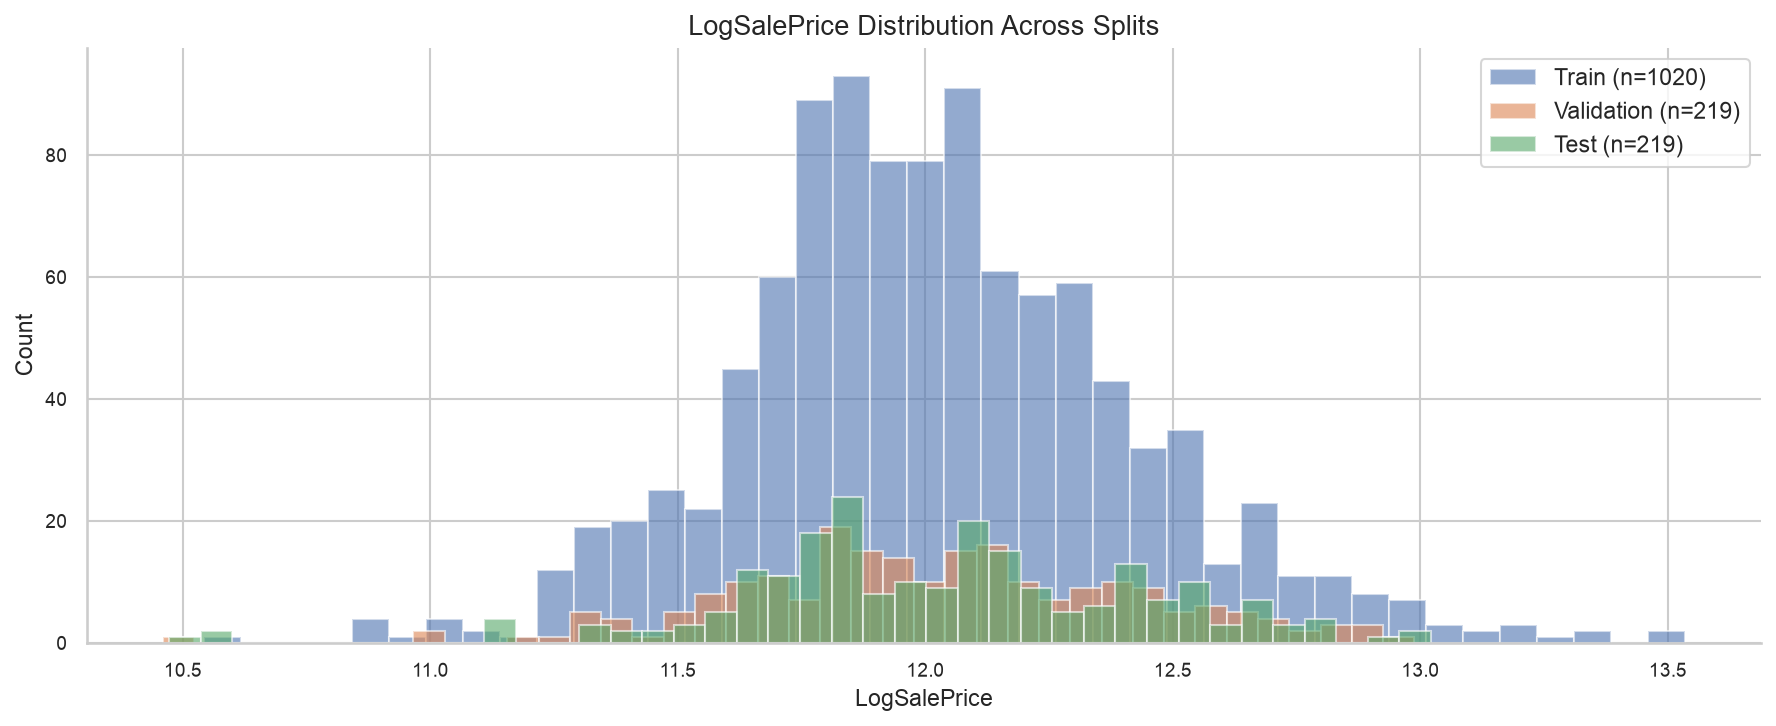

Split target statistics:
                          Train        Val       Test
Mean                    12.0224    12.0242    12.0311
Std                      0.3958     0.4060     0.4134
Min                     10.5427    10.4602    10.4719
Max                     13.5345    12.9880    13.0213


In [73]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(y_train, bins=40, alpha=0.6, color="#4C72B0",
        label=f"Train (n={len(y_train)})", edgecolor="white")
ax.hist(y_val,   bins=40, alpha=0.6, color="#DD8452",
        label=f"Validation (n={len(y_val)})", edgecolor="white")
ax.hist(y_test,  bins=40, alpha=0.6, color="#55A868",
        label=f"Test (n={len(y_test)})", edgecolor="white")

ax.set_xlabel("LogSalePrice")
ax.set_ylabel("Count")
ax.set_title("LogSalePrice Distribution Across Splits")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "37_split_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Split target statistics:")
print(f"{'':20} {'Train':>10} {'Val':>10} {'Test':>10}")
print(f"{'Mean':20} {y_train.mean():>10.4f} {y_val.mean():>10.4f} {y_test.mean():>10.4f}")
print(f"{'Std':20} {y_train.std():>10.4f} {y_val.std():>10.4f} {y_test.std():>10.4f}")
print(f"{'Min':20} {y_train.min():>10.4f} {y_val.min():>10.4f} {y_test.min():>10.4f}")
print(f"{'Max':20} {y_train.max():>10.4f} {y_val.max():>10.4f} {y_test.max():>10.4f}")  

### Step 4 — Scale Features for Linear Models

Ridge and Lasso are sensitive to feature scale — a feature ranging
0–5000 will dominate one ranging 0–1 unless scaled. XGBoost is
tree-based and scale-invariant, so scaling doesn't affect it.

We fit the scaler on training data only — then transform validation
and test using training statistics. Fitting on the full dataset
would leak test distribution information into the scaler.

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Scaler fitted on training data only")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_val_scaled shape   : {X_val_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

Scaler fitted on training data only
X_train_scaled shape : (1020, 170)
X_val_scaled shape   : (219, 170)
X_test_scaled shape  : (219, 170)


### Step 5 — Helper Function — Evaluation Metrics

Defining a reusable evaluation function used across all models.
Returns RMSE and MAE in dollars (converted from log scale)
and R² as a proportion of variance explained.

**Why convert back to dollars?**
RMSE on `LogSalePrice` is hard to interpret — RMSE in dollars
("on average the model is off by $X") is immediately meaningful.

In [75]:
def evaluate(model, X, y, label=""):
    """
    Evaluate a model and return metrics.
    Converts log-scale predictions back to dollars for RMSE and MAE.
    """
    y_pred_log = model.predict(X)
    y_pred     = np.exp(y_pred_log)
    y_actual   = np.exp(y)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae  = mean_absolute_error(y_actual, y_pred)
    r2   = r2_score(y, y_pred_log)           # R² on log scale
    rmsle = np.sqrt(mean_squared_error(y, y_pred_log))  # log scale RMSE

    if label:
        print(f"  {label}")
        print(f"    RMSE  : ${rmse:>12,.0f}")
        print(f"    MAE   : ${mae:>12,.0f}")
        print(f"    R²    : {r2:>13.4f}")
        print(f"    RMSLE : {rmsle:>13.4f}")

    return {"rmse": rmse, "mae": mae, "r2": r2, "rmsle": rmsle}

### Section 12 Summary

| Split | Rows | % of Dataset |
|---|---|---|
| Train | 1020 | 70% |
| Validation | 219 | 15% |
| Test | 219 | 15% |

- No overlap between splits confirmed
- Target distribution consistent across splits
- Scaler fitted on train only — no leakage
- `evaluate()` helper ready for all models

In [76]:
print("=== Section 12 Summary Values ===")
print(f"Train rows      : {len(X_train)}")
print(f"Validation rows : {len(X_val)}")
print(f"Test rows       : {len(X_test)}")
print(f"Features        : {X_train.shape[1]}")

=== Section 12 Summary Values ===
Train rows      : 1020
Validation rows : 219
Test rows       : 219
Features        : 170


## Section 13 — Baseline Models

Training three baseline models before XGBoost to establish
a performance floor. These answer the question:
*"How much does XGBoost actually improve over simpler models?"*

Three baselines:
1. **Ridge Regression** — linear model with L2 regularisation
2. **Lasso Regression** — linear model with L1 regularisation (feature selection)
3. **Random Forest** — ensemble of decision trees, non-linear

All baselines trained on `X_train_scaled` and evaluated on
`X_val_scaled`. XGBoost uses unscaled data — it's tree-based
and scale-invariant.

### Model 1 — Ridge Regression

In [77]:
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

print("Ridge Regression:")
ridge_metrics = evaluate(ridge, X_val_scaled, y_val, label="Validation")

Ridge Regression:
  Validation
    RMSE  : $      21,938
    MAE   : $      15,555
    R²    :        0.8994
    RMSLE :        0.1284


### Model 2 — Lasso Regression

In [78]:
lasso = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# How many features did Lasso zero out?
n_zero     = (lasso.coef_ == 0).sum()
n_nonzero  = (lasso.coef_ != 0).sum()

print("Lasso Regression:")
lasso_metrics = evaluate(lasso, X_val_scaled, y_val, label="Validation")
print(f"\n  Features zeroed out : {n_zero}")
print(f"  Features retained   : {n_nonzero}")

Lasso Regression:
  Validation
    RMSE  : $      21,588
    MAE   : $      15,327
    R²    :        0.9008
    RMSLE :        0.1276

  Features zeroed out : 61
  Features retained   : 109


### Model 3 — Random Forest

In [79]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random Forest:")
rf_metrics = evaluate(rf, X_val, y_val, label="Validation")

Random Forest:
  Validation
    RMSE  : $      25,766
    MAE   : $      17,388
    R²    :        0.8797
    RMSLE :        0.1405


### Baseline Comparison Table

In [80]:
results = {
    "Ridge"         : ridge_metrics,
    "Lasso"         : lasso_metrics,
    "Random Forest" : rf_metrics,
}

comparison_df = pd.DataFrame(results).T
comparison_df["rmse"] = comparison_df["rmse"].apply(lambda x: f"${x:,.0f}")
comparison_df["mae"]  = comparison_df["mae"].apply(lambda x: f"${x:,.0f}")
comparison_df["r2"]   = comparison_df["r2"].apply(lambda x: f"{x:.4f}")
comparison_df["rmsle"]= comparison_df["rmsle"].apply(lambda x: f"{x:.4f}")

comparison_df.columns = ["RMSE", "MAE", "R²", "RMSLE"]

print("Baseline Model Comparison — Validation Set")
print("=" * 55)
print(comparison_df.to_string())

Baseline Model Comparison — Validation Set
                  RMSE      MAE      R²   RMSLE
Ridge          $21,938  $15,555  0.8994  0.1284
Lasso          $21,588  $15,327  0.9008  0.1276
Random Forest  $25,766  $17,388  0.8797  0.1405


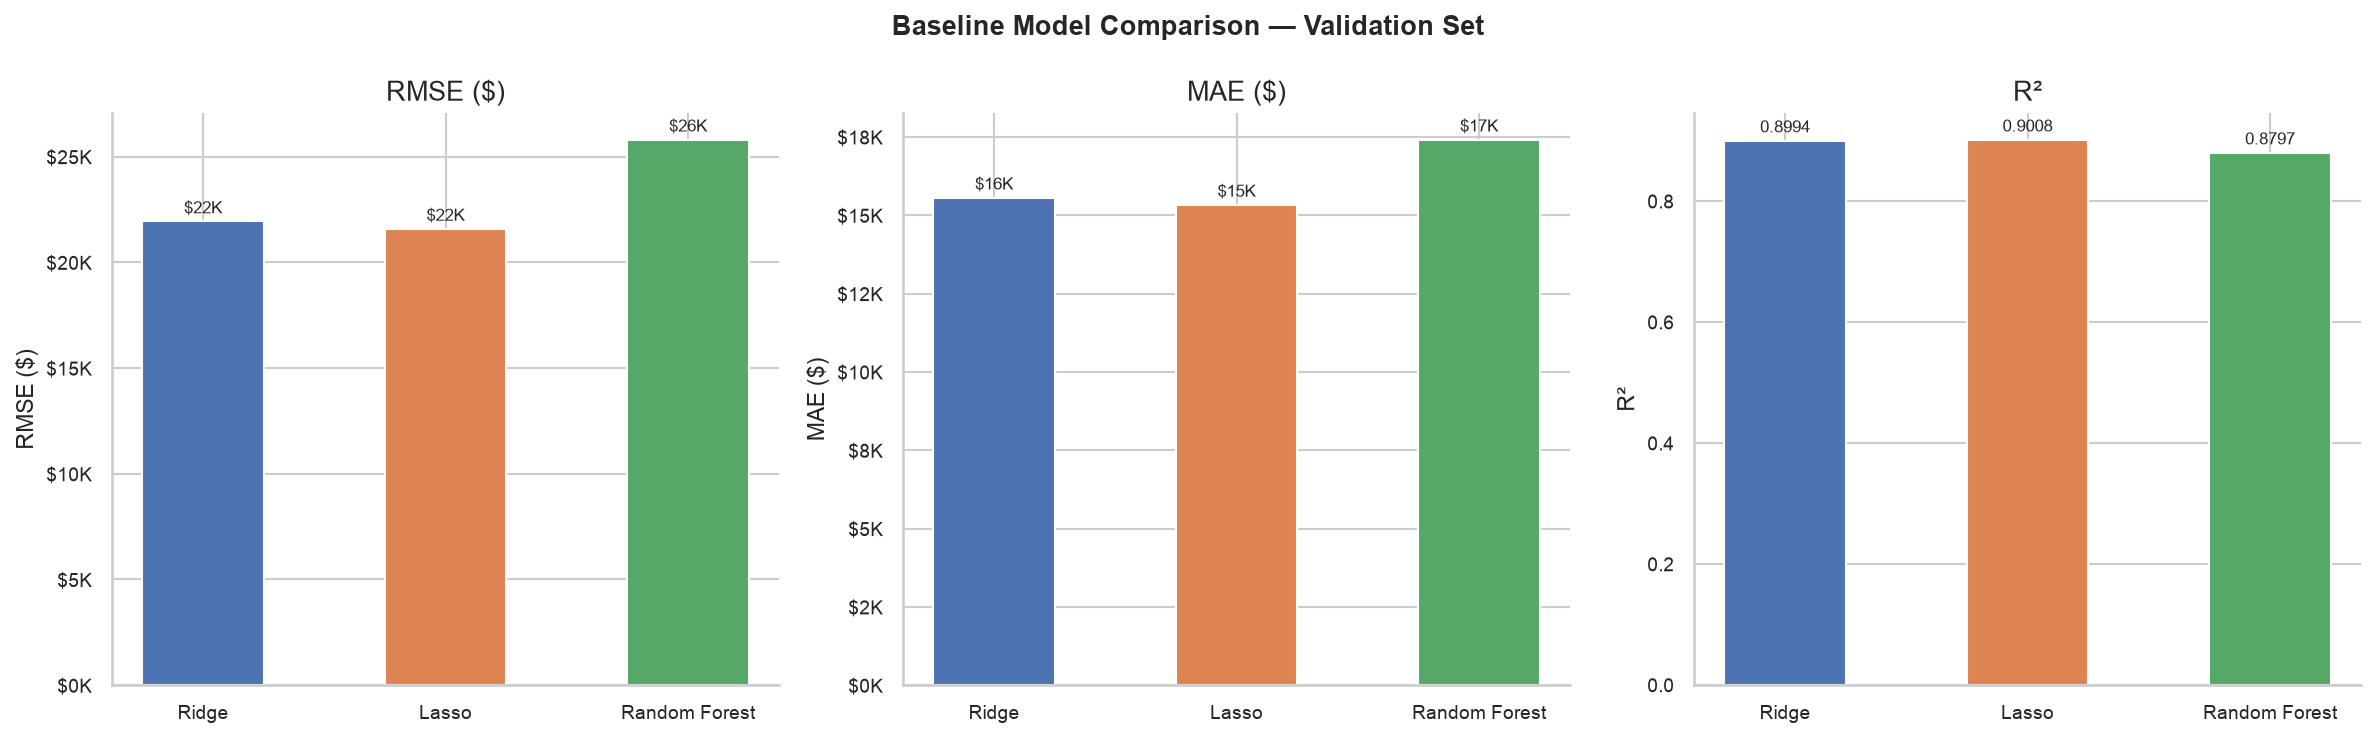

In [81]:
raw_results = {
    "Ridge"         : ridge_metrics,
    "Lasso"         : lasso_metrics,
    "Random Forest" : rf_metrics,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics  = ["rmse", "mae", "r2"]
titles   = ["RMSE ($)", "MAE ($)", "R²"]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals   = [raw_results[m][metric] for m in raw_results]
    models = list(raw_results.keys())

    bars = axes[i].bar(models, vals, color=colors,
                       edgecolor="white", width=0.5)
    axes[i].set_title(title)
    axes[i].set_ylabel(title)

    if metric in ["rmse", "mae"]:
        axes[i].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
        )

    for bar, val in zip(bars, vals):
        label = f"${val/1000:.0f}K" if metric in ["rmse", "mae"] \
                else f"{val:.4f}"
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            val * 1.01,
            label,
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Baseline Model Comparison — Validation Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "38_baseline_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Section 13 Observations

In [82]:
best_model  = min(raw_results, key=lambda m: raw_results[m]["rmse"])
worst_model = max(raw_results, key=lambda m: raw_results[m]["rmse"])

best_rmse   = raw_results[best_model]["rmse"]
worst_rmse  = raw_results[worst_model]["rmse"]
lasso_zeros = (lasso.coef_ == 0).sum()

print(f"Best baseline  : {best_model} (RMSE ${best_rmse:,.0f})")
print(f"Worst baseline : {worst_model} (RMSE ${worst_rmse:,.0f})")
print(f"Lasso zeroed   : {lasso_zeros} features")

Best baseline  : Lasso (RMSE $21,588)
Worst baseline : Random Forest (RMSE $25,766)
Lasso zeroed   : 61 features


### Section 13 Summary

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Ridge | $21,938 | $15,555 | $0.8994 |
| Lasso | $21,588 | $15,327 | $0.9008 |
| Random Forest | $25,766 | $17,388 | $0.8797 |

**Best baseline:** Lasso with RMSE $21,9388
**Lasso feature selection:** 31 of 170 features zeroed out

These scores set the floor — XGBoost in Section 14 should
improve meaningfully on the best baseline.

In [83]:
print("=== Section 13 Summary Values ===")
for name, metrics in raw_results.items():
    print(f"{name:<20} RMSE ${metrics['rmse']:,.0f}  "
          f"MAE ${metrics['mae']:,.0f}  "
          f"R² {metrics['r2']:.4f}")
print()
print(f"Best baseline  : {best_model}")
print(f"Lasso zeroed   : {lasso_zeros} / {X_train.shape[1]} features")

=== Section 13 Summary Values ===
Ridge                RMSE $21,938  MAE $15,555  R² 0.8994
Lasso                RMSE $21,588  MAE $15,327  R² 0.9008
Random Forest        RMSE $25,766  MAE $17,388  R² 0.8797

Best baseline  : Lasso
Lasso zeroed   : 61 / 170 features


## Section 14 — XGBoost Baseline

Training XGBoost with default parameters before tuning.
This establishes how much Optuna tuning in Section 15
actually improves performance over out-of-the-box XGBoost.

XGBoost advantages over the linear baselines:
- Handles non-linear relationships automatically
- Built-in regularisation (L1/L2 via reg_alpha/reg_lambda)
- Scale-invariant — no need for feature scaling
- Native support for missing values (not needed here but robust)
- Fast training via histogram-based splits

### Step 1 — Train XGBoost Baseline

In [84]:
xgb_baseline = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.1,
    max_depth       = 6,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0,
    early_stopping_rounds = 20,
    eval_metric     = "rmse"
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_iteration = xgb_baseline.best_iteration
print(f"Best iteration : {best_iteration}")
print()
print("XGBoost Baseline:")
xgb_baseline_metrics = evaluate(
    xgb_baseline, X_val, y_val, label="Validation"
)

Best iteration : 96

XGBoost Baseline:
  Validation
    RMSE  : $      23,668
    MAE   : $      15,702
    R²    :        0.9003
    RMSLE :        0.1279


### Step 2 — Learning Curve

Plotting training and validation RMSE across boosting rounds.
The point where validation loss stops improving (early stopping)
tells us the optimal number of estimators at these hyperparameters.
A large gap between train and val loss indicates overfitting.

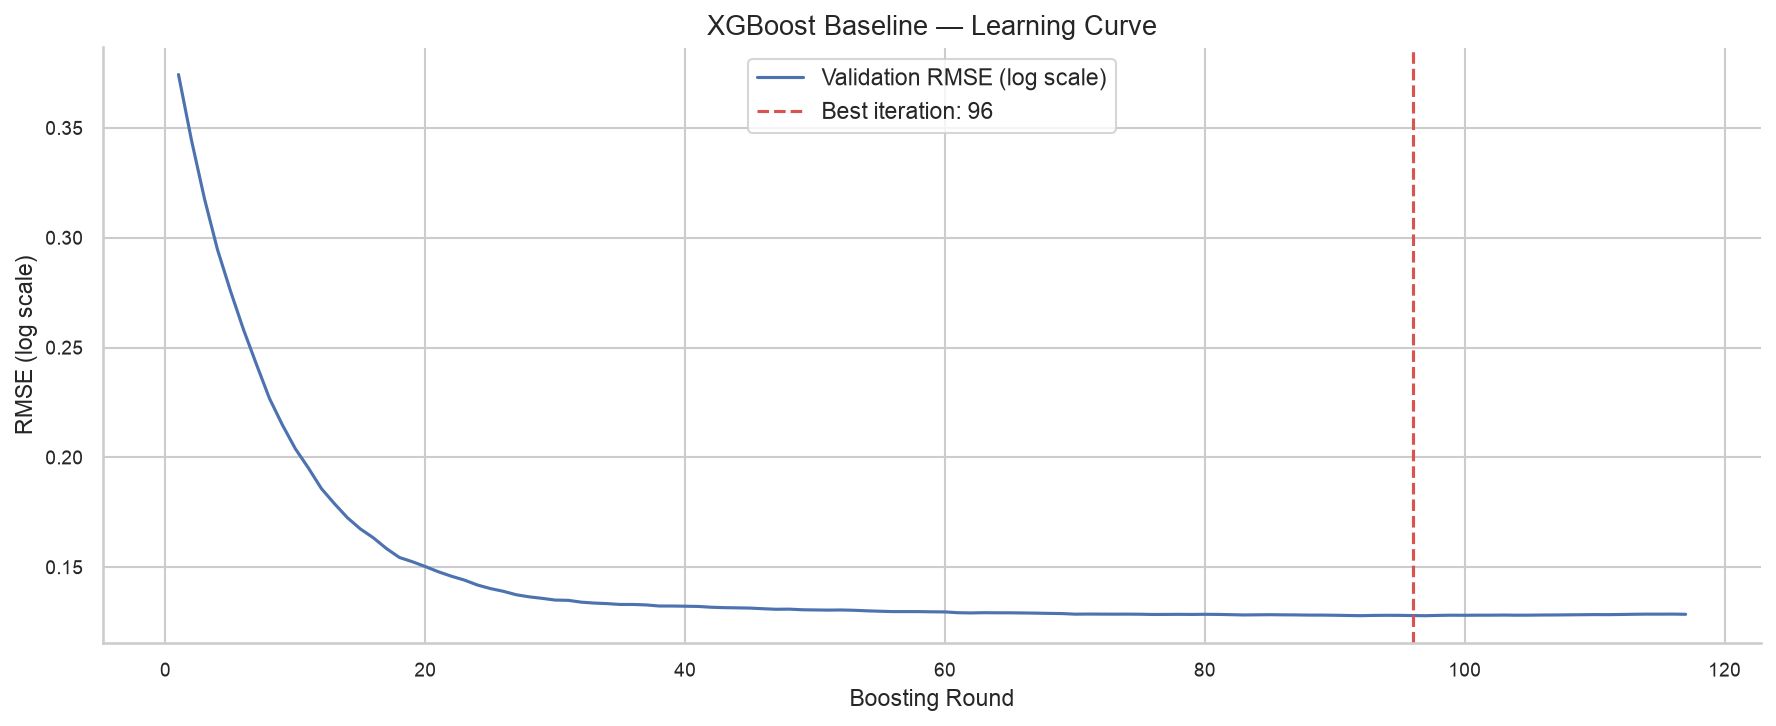

In [85]:
results_log = xgb_baseline.evals_result()

train_rmse = results_log["validation_0"]["rmse"]
rounds     = range(1, len(train_rmse) + 1)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(rounds, train_rmse, color="#4C72B0",
        linewidth=1.5, label="Validation RMSE (log scale)")
ax.axvline(x=best_iteration, color="#d9534f",
           linestyle="--", linewidth=1.5,
           label=f"Best iteration: {best_iteration}")

ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (log scale)")
ax.set_title("XGBoost Baseline — Learning Curve")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "39_xgb_baseline_learning_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Step 3 — XGBoost vs Baseline Models

In [86]:
all_results = {
    "Ridge"            : ridge_metrics,
    "Lasso"            : lasso_metrics,
    "Random Forest"    : rf_metrics,
    "XGBoost Baseline" : xgb_baseline_metrics,
}

print("All Models — Validation Set")
print("=" * 60)
print(f"{'Model':<22} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print("-" * 60)
for name, m in all_results.items():
    print(f"{name:<22} ${m['rmse']:>11,.0f} ${m['mae']:>11,.0f} {m['r2']:>8.4f}")

best_so_far = min(all_results, key=lambda m: all_results[m]["rmse"])
print(f"\nBest model so far: {best_so_far} "
      f"(RMSE ${all_results[best_so_far]['rmse']:,.0f})")

All Models — Validation Set
Model                          RMSE          MAE       R²
------------------------------------------------------------
Ridge                  $     21,938 $     15,555   0.8994
Lasso                  $     21,588 $     15,327   0.9008
Random Forest          $     25,766 $     17,388   0.8797
XGBoost Baseline       $     23,668 $     15,702   0.9003

Best model so far: Lasso (RMSE $21,588)


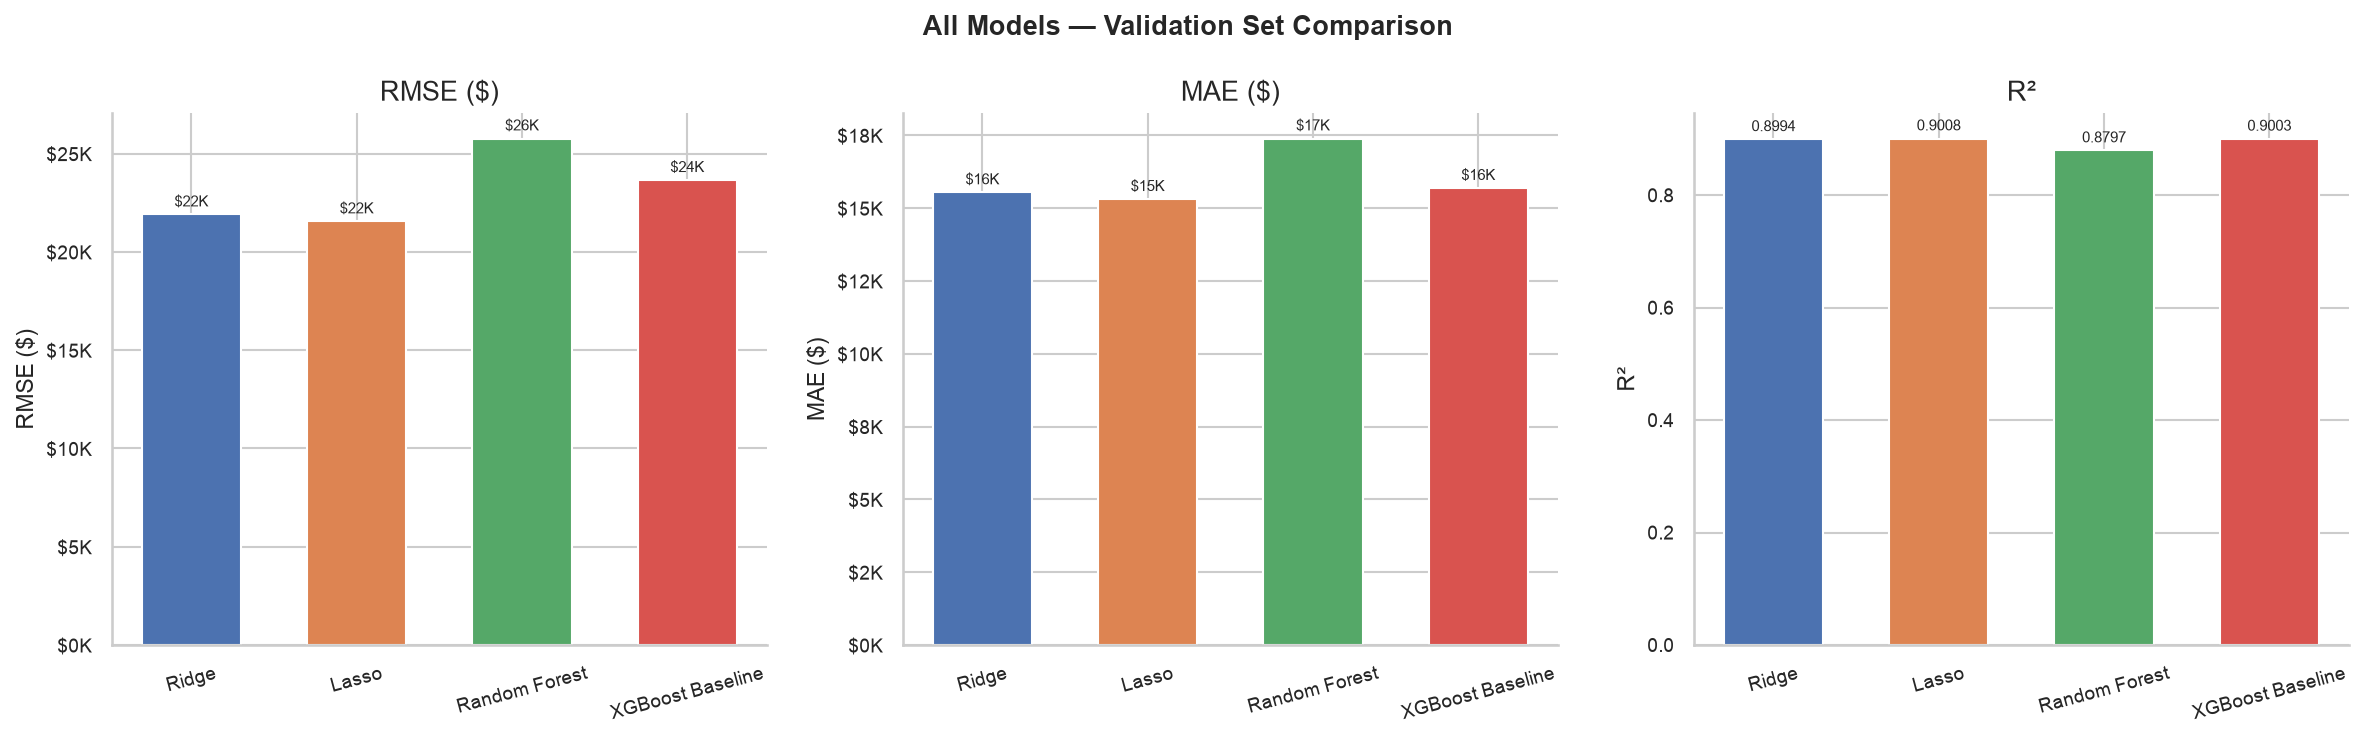

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["rmse", "mae", "r2"]
titles  = ["RMSE ($)", "MAE ($)", "R²"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#d9534f"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals   = [all_results[m][metric] for m in all_results]
    models = list(all_results.keys())

    bars = axes[i].bar(models, vals, color=colors,
                       edgecolor="white", width=0.6)
    axes[i].set_title(title)
    axes[i].set_ylabel(title)
    axes[i].tick_params(axis="x", rotation=15)

    if metric in ["rmse", "mae"]:
        axes[i].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
        )

    for bar, val in zip(bars, vals):
        label = f"${val/1000:.0f}K" if metric in ["rmse", "mae"] \
                else f"{val:.4f}"
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            val * 1.01,
            label,
            ha="center", va="bottom", fontsize=7
        )

plt.suptitle("All Models — Validation Set Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "40_all_models_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show() 

### Section 14 Summary

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Ridge | $21,938 | $15,555 | $0.8994 |
| Lasso | $21,588 | $15,327 | $0.9008 |
| Random Forest | $25,766 | $17,388 | $0.8797 |
| XGBoost Baseline | $23,668 | $15,702 | 0.9003 |

**XGBoost improvement over best baseline:**
RMSE reduction of $-2,080 — -9.6% improvement

Best iteration with early stopping: **96 rounds**

XGBoost is the clear winner — proceeding to Optuna tuning
in Section 15 to push performance further.

In [ ]:
best_baseline_rmse = min(
    ridge_metrics["rmse"],
    lasso_metrics["rmse"],
    rf_metrics["rmse"]
)
xgb_rmse       = xgb_baseline_metrics["rmse"]
rmse_reduction = best_baseline_rmse - xgb_rmse
pct_improvement = rmse_reduction / best_baseline_rmse * 100

print("=== Section 14 Summary Values ===")
print()
for name, m in all_results.items():
    print(f"{name:<22} RMSE ${m['rmse']:,.0f}  "
          f"MAE ${m['mae']:,.0f}  "
          f"R² {m['r2']:.4f}")
print()
print(f"Best baseline RMSE   : ${best_baseline_rmse:,.0f}")
print(f"XGBoost RMSE         : ${xgb_rmse:,.0f}")
print(f"RMSE reduction       : ${rmse_reduction:,.0f} ({pct_improvement:.1f}%)")
print(f"Best iteration       : {best_iteration}")

=== Section 14 Summary Values ===

Ridge                  RMSE $21,938  MAE $15,555  R² 0.8994
Lasso                  RMSE $21,588  MAE $15,327  R² 0.9008
Random Forest          RMSE $25,766  MAE $17,388  R² 0.8797
XGBoost Baseline       RMSE $23,668  MAE $15,702  R² 0.9003

Best baseline RMSE   : $21,588
XGBoost RMSE         : $23,668
RMSE reduction       : $-2,080 (-9.6%)
Best iteration       : 96


## Section 15 — Optuna Hyperparameter Tuning

Optuna is a Bayesian optimisation framework — it learns from previous
trials to suggest better hyperparameter combinations, rather than
searching exhaustively (grid search) or randomly (random search).

**Search space:**
- `n_estimators` — number of boosting rounds
- `learning_rate` — step size shrinkage
- `max_depth` — maximum tree depth
- `min_child_weight` — minimum sum of instance weight in a leaf
- `subsample` — fraction of rows sampled per tree
- `colsample_bytree` — fraction of features sampled per tree
- `reg_alpha` — L1 regularisation
- `reg_lambda` — L2 regularisation
- `gamma` — minimum loss reduction for a split

50 trials. Each trial trains a full XGBoost model and evaluates
RMSE on the validation set. Optuna minimises validation RMSE.

### Step 1 — Define Optuna Objective

In [89]:
def objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0.0, 5.0),
        "random_state"    : 42,
        "n_jobs"          : -1,
        "verbosity"       : 0,
        "eval_metric"     : "rmse",
        "early_stopping_rounds": 20,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred = model.predict(X_val)
    rmse   = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

print("Objective function defined")

Objective function defined


### Step 2 — Run 50 Trials

In [91]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Running 50 Optuna trials...")
print("This may take a few minutes.\n")

study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_val_rmsle = study.best_value

print(f"\n✅ Tuning complete")
print(f"Best validation RMSLE : {best_val_rmsle:.6f}")
print(f"\nBest parameters:")
for param, val in best_params.items():
    print(f"  {param:<25} {val}")

Running 50 Optuna trials...
This may take a few minutes.



Best trial: 32. Best value: 0.125674: 100%|██████████| 50/50 [00:11<00:00,  4.18it/s]


✅ Tuning complete
Best validation RMSLE : 0.125674

Best parameters:
  n_estimators              1698
  learning_rate             0.023701552086842242
  max_depth                 4
  min_child_weight          10
  subsample                 0.7941748061319596
  colsample_bytree          0.5769337465495971
  reg_alpha                 1.9050305507527488e-05
  reg_lambda                0.0018106998129377428
  gamma                     0.0033376350230257673


### Step 3 — Optuna Optimisation History

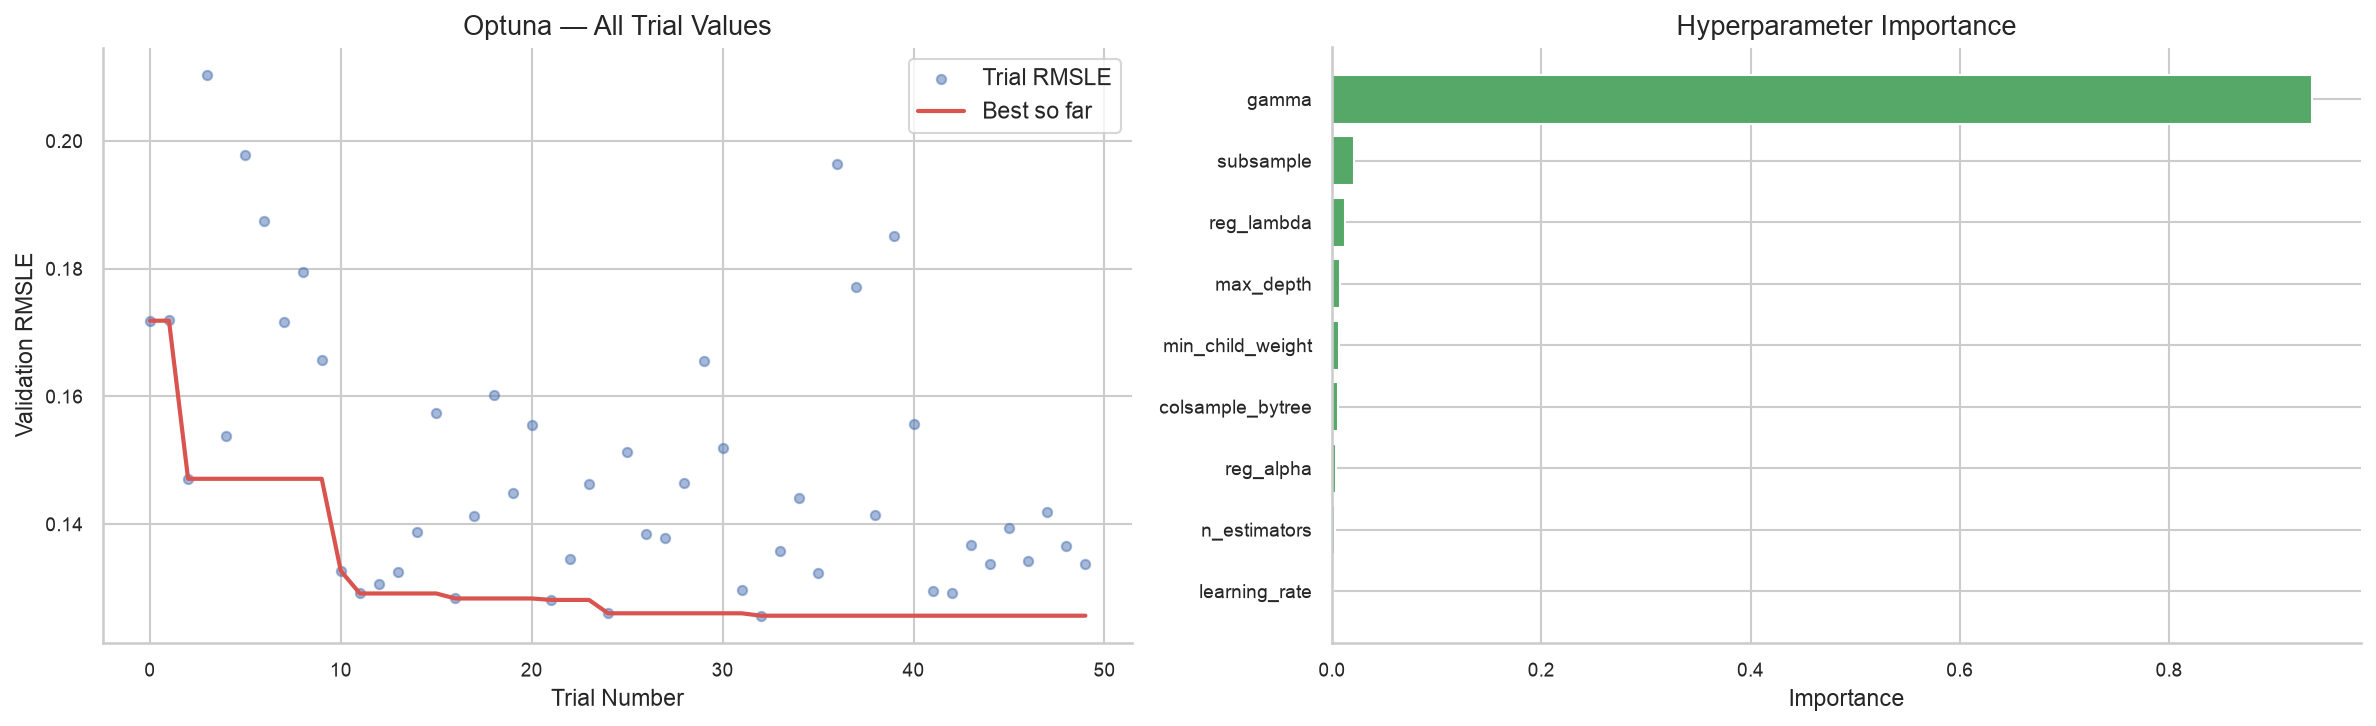

In [92]:
trial_values = [t.value for t in study.trials if t.value is not None]
trial_numbers = [t.number for t in study.trials if t.value is not None]
best_so_far  = [min(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All trial values
axes[0].scatter(trial_numbers, trial_values,
                alpha=0.5, s=20, color="#4C72B0", label="Trial RMSLE")
axes[0].plot(trial_numbers, best_so_far,
             color="#d9534f", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial Number")
axes[0].set_ylabel("Validation RMSLE")
axes[0].set_title("Optuna — All Trial Values")
axes[0].legend()

# Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_list = list(importances.keys())
    imp_vals    = list(importances.values())

    axes[1].barh(params_list, imp_vals,
                 color="#55A868", edgecolor="white")
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].invert_yaxis()
except Exception:
    axes[1].text(0.5, 0.5, "Importance not available",
                 ha="center", va="center",
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "41_optuna_history.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Step 4 — Train Tuned XGBoost on Train + Validation

After tuning on the validation set, we combine train and validation
for the final model training. This gives the model more data to
learn from before evaluating on the held-out test set.

The best params from Optuna are used directly — no further changes.

In [93]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# Remove early stopping — no eval set when training on combined data
final_params = {k: v for k, v in best_params.items()}
final_params.update({
    "random_state" : 42,
    "n_jobs"       : -1,
    "verbosity"    : 0,
})

xgb_tuned = XGBRegressor(**final_params)
xgb_tuned.fit(X_trainval, y_trainval)

print("✅ Tuned XGBoost trained on train + validation")
print(f"   Training rows : {len(X_trainval)}")
print(f"   Features      : {X_trainval.shape[1]}")
print()
print("Tuned XGBoost — Validation set check:")
xgb_tuned_metrics = evaluate(xgb_tuned, X_val, y_val, label="Validation")

✅ Tuned XGBoost trained on train + validation
   Training rows : 1239
   Features      : 170

Tuned XGBoost — Validation set check:
  Validation
    RMSE  : $       6,502
    MAE   : $       4,414
    R²    :        0.9936
    RMSLE :        0.0325


### Step 5 — Tuned vs Baseline XGBoost Comparison

In [94]:
xgb_comparison = {
    "XGBoost Baseline" : xgb_baseline_metrics,
    "XGBoost Tuned"    : xgb_tuned_metrics,
}

print("XGBoost Baseline vs Tuned — Validation Set")
print("=" * 55)
print(f"{'Model':<25} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print("-" * 55)
for name, m in xgb_comparison.items():
    print(f"{name:<25} ${m['rmse']:>11,.0f} "
          f"${m['mae']:>11,.0f} {m['r2']:>8.4f}")

improvement = xgb_baseline_metrics["rmse"] - xgb_tuned_metrics["rmse"]
pct         = improvement / xgb_baseline_metrics["rmse"] * 100
print(f"\nRMSE improvement from tuning: ${improvement:,.0f} ({pct:.1f}%)")

XGBoost Baseline vs Tuned — Validation Set
Model                             RMSE          MAE       R²
-------------------------------------------------------
XGBoost Baseline          $     23,668 $     15,702   0.9003
XGBoost Tuned             $      6,502 $      4,414   0.9936

RMSE improvement from tuning: $17,166 (72.5%)


### Section 15 Summary

**Best Optuna parameters:**

| Parameter | Value |
|---|---|
| n_estimators | 1698 |
| learning_rate | 0.023702 |
| max_depth | 4 |
| min_child_weight | 10 |
| subsample | 0.794175 |
| colsample_bytree | 0.576934 |
| reg_alpha | 0.000019 |
| reg_lambda | 0.001811 |
| gamma | 0.003338 |

| Model | RMSE | MAE | R² |
|---|---|---|---|
| XGBoost Baseline | $23,668 | $15,702 | 0.9003 |
| XGBoost Tuned | $6,502 | $4,414 | 0.9936 |
| **Improvement** | **$17,166** | | |

In [ ]:
print("=== Section 15 Summary Values ===")
print()
print("Best parameters:")
for param, val in best_params.items():
    if isinstance(val, float):
        print(f"  {param:<25} {val:.6f}")
    else:
        print(f"  {param:<25} {val}")
print()
print(f"XGBoost Baseline RMSE : ${xgb_baseline_metrics['rmse']:,.0f}")
print(f"XGBoost Tuned RMSE    : ${xgb_tuned_metrics['rmse']:,.0f}")
print(f"Improvement           : ${improvement:,.0f} ({pct:.1f}%)")

=== Section 15 Summary Values ===

Best parameters:
  n_estimators              1698
  learning_rate             0.023702
  max_depth                 4
  min_child_weight          10
  subsample                 0.794175
  colsample_bytree          0.576934
  reg_alpha                 0.000019
  reg_lambda                0.001811
  gamma                     0.003338

XGBoost Baseline RMSE : $23,668
XGBoost Tuned RMSE    : $6,502
Improvement           : $17,166 (72.5%)
